In [1]:
# ============================================================================
# CELL 1: IMPORTS & CONFIGURATION
# ============================================================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats
from itertools import combinations

sns.set_style("whitegrid")

PUB_STYLE = {
    'font.family'      : 'serif',
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'legend.fontsize'  : 9,
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
}

# Position-specific stat lists — same as data prep
STATS_FWD = ['KP', 'PrgP', 'PrgC', 'SCA', 'Goals', 'Assists', 'xG', 'npxG', 'GCA', 'PPA']
STATS_MID = ['KP', 'PrgP', 'PrgC', 'SCA', 'GCA', 'PPA', 'PassPct', 'PrgDist']
STATS_DEF = ['TklW', 'Int', 'Clr', 'Blocks', 'PrgP', 'PassPct']

POS_STATS_MAP = {
    'FWD': STATS_FWD,
    'MID': STATS_MID,
    'DEF': STATS_DEF,
}

# Union of all metrics — must match data prep script
ALL_METRICS = sorted(set(STATS_FWD + STATS_MID + STATS_DEF))

# Stability thresholds for classification (used in tables & figures)
# Based on ICC / Pearson r conventions in sports science literature
THRESH_HIGH   = 0.70   # r ≥ 0.70 → high stability
THRESH_MOD    = 0.50   # r ≥ 0.50 → moderate stability
                       # r <  0.50 → low stability

VALID_LEAGUES = ['Premier League', 'Ligue 1', 'Bundesliga', 'Serie A', 'La Liga']

LEAGUE_MAP = {
    'Ligue 1': 0, 'Bundesliga': 1, 'Serie A': 2,
    'La Liga': 3, 'Premier League': 4
}

AGE_GROUPS   = ['Young (U23)', 'Prime (23-29)', 'Veteran (30+)']
POS_BUCKETS  = ['FWD', 'MID', 'DEF']

# Playing time threshold — must match data prep script
MIN_90S      = 5.0
MIN_90S_SWEEP = [3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0]

# Colours — consistent across all figures
POS_COLOURS  = {'FWD': '#E8534A', 'MID': '#4A90D9', 'DEF': '#5BAD6F'}
STAB_COLOURS = {'High': '#2166AC', 'Moderate': '#F4A736', 'Low': '#D73027'}

def save_fig(name, fig):
    fig.savefig(f'{name}.pdf', bbox_inches='tight', dpi=300)
    fig.savefig(f'{name}.png', bbox_inches='tight', dpi=300)
    print(f"Saved: {name}.pdf / .png")

print("✓ Configuration set")
print(f"\n  Position stat counts: FWD={len(STATS_FWD)}, MID={len(STATS_MID)}, DEF={len(STATS_DEF)}")
print(f"  Stability thresholds: High ≥ {THRESH_HIGH}, Moderate ≥ {THRESH_MOD}, Low < {THRESH_MOD}")

✓ Configuration set

  Position stat counts: FWD=10, MID=8, DEF=6
  Stability thresholds: High ≥ 0.7, Moderate ≥ 0.5, Low < 0.5


In [2]:
# ============================================================================
# CELL 2: LOAD PANEL
# ============================================================================

panel = pd.read_csv('metric_stability_panel.csv')

print(f"  Panel loaded: {len(panel)} rows × {len(panel.columns)} cols")
print(f"  Unique players : {panel['Player_Key'].nunique()}")
print(f"  Season pairs   : {panel['Pair'].nunique()}")
print(f"  Leagues        : {sorted(panel['Comp_t'].unique())}")

print(f"\n  Position breakdown:")
for pos in POS_BUCKETS:
    n = (panel['Pos_Bucket_t'] == pos).sum()
    print(f"    {pos}: {n} ({n/len(panel)*100:.1f}%)")

print(f"\n  Age group breakdown:")
for grp in AGE_GROUPS:
    n = (panel['Age_Group'] == grp).sum()
    print(f"    {grp}: {n} ({n/len(panel)*100:.1f}%)")

  Panel loaded: 8993 rows × 83 cols
  Unique players : 3061
  Season pairs   : 7
  Leagues        : ['Bundesliga', 'La Liga', 'Ligue 1', 'Premier League', 'Serie A']

  Position breakdown:
    FWD: 2162 (24.0%)
    MID: 3096 (34.4%)
    DEF: 3735 (41.5%)

  Age group breakdown:
    Young (U23): 2272 (25.3%)
    Prime (23-29): 5210 (57.9%)
    Veteran (30+): 1511 (16.8%)


In [3]:
# ============================================================================
# CELL 3: CORE STABILITY COMPUTATION
# ============================================================================
# For each position × metric combination:
#   - Pearson r  (year-to-year correlation on raw counts, primary metric)
#   - ICC(2,1)   (two-way random, absolute agreement, on per-90 rates)
#                Per-90 removes playing-time scale so ICC reflects
#                genuine rate consistency, not just volume persistence.
#   - 95% CI on Pearson r via Fisher z-transformation
# ============================================================================

panel_full = panel.copy()   # keep full panel for Cell 10b sweep
panel = panel[
    (panel['90s_t']  >= MIN_90S) &
    (panel['90s_t1'] >= MIN_90S)
].copy()

print(f"  Applied MIN_90S={MIN_90S} filter:")
print(f"    Full panel : {len(panel_full)} rows")
print(f"    Filtered   : {len(panel)} rows")
print(f"    Removed    : {len(panel_full) - len(panel)} rows\n")

def pearson_with_ci(x, y, alpha=0.05):
    """Pearson r with 95% CI via Fisher z-transformation."""
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x, y = x[mask], y[mask]
    n = len(x)
    if n < 10:
        return np.nan, np.nan, np.nan, n
    r, p = stats.pearsonr(x, y)
    z     = np.arctanh(np.clip(r, -0.9999, 0.9999))
    se    = 1 / np.sqrt(n - 3)
    z_crit = stats.norm.ppf(1 - alpha / 2)
    ci_lo = np.tanh(z - z_crit * se)
    ci_hi = np.tanh(z + z_crit * se)
    return r, ci_lo, ci_hi, n


def icc_2way_absolute(x, y):
    """
    ICC(2,1) — two-way random effects, absolute agreement.
    Computed on per-90 rates to remove playing-time scale inflation.
    Formula follows Shrout & Fleiss (1979), Case 2 absolute agreement.
    """
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x, y = x[mask], y[mask]
    n = len(x)
    if n < 10:
        return np.nan
    k = 2  # two raters (season t and t+1)

    grand_mean = (x.mean() + y.mean()) / 2
    row_means  = (x + y) / 2

    # Mean squares
    ss_r = k * np.sum((row_means - grand_mean) ** 2)
    ms_r = ss_r / (n - 1)

    col_means = np.array([x.mean(), y.mean()])
    ss_c = n * np.sum((col_means - grand_mean) ** 2)
    ms_c = ss_c / (k - 1)

    ss_total = np.sum((x - grand_mean) ** 2) + np.sum((y - grand_mean) ** 2)
    ss_e = ss_total - ss_r - ss_c
    ms_e = ss_e / ((n - 1) * (k - 1))
    ms_e = max(ms_e, 1e-10)

    # ICC(2,1) absolute agreement
    icc = (ms_r - ms_e) / (ms_r + (k - 1) * ms_e + (k / n) * (ms_c - ms_e))
    return float(np.clip(icc, -1, 1))


def get_per90_col(metric, df_cols):
    """
    Return the per-90 column name if available, else None.
    PassPct is already a rate — use raw directly.
    """
    if metric == 'PassPct':
        return None   # use raw
    p90_col = f'{metric}_p90'
    return p90_col if p90_col in df_cols else None


print("Computing stability metrics...\n")
print(f"  {'Pos':<5} {'Metric':<10} {'N':>6} {'Pearson r':>10} "
      f"{'95% CI':>20} {'ICC(p90)':>10} {'Stability':>12}")
print(f"  {'-'*80}")

stability_rows = []

for pos in POS_BUCKETS:
    stats_list = POS_STATS_MAP[pos]
    df_pos     = panel[panel['Pos_Bucket_t'] == pos].copy()

    for metric in stats_list:
        col_t  = f'{metric}_t'
        col_t1 = f'{metric}_t1'

        if col_t not in df_pos.columns or col_t1 not in df_pos.columns:
            print(f"  ⚠  {pos} {metric}: columns not found — skipping")
            continue

        # Pearson r on raw counts
        x_raw = df_pos[col_t].values.astype(float)
        y_raw = df_pos[col_t1].values.astype(float)
        r, ci_lo, ci_hi, n = pearson_with_ci(x_raw, y_raw)

        # ICC on per-90 rates (removes playing-time scale)
        p90_t  = get_per90_col(metric, df_pos.columns)
        if p90_t is not None:
            p90_t1 = f'{metric}_p90_t1'
            p90_t_col = f'{metric}_p90_t'
            if p90_t_col in df_pos.columns and p90_t1 in df_pos.columns:
                x_p90 = df_pos[p90_t_col].values.astype(float)
                y_p90 = df_pos[p90_t1].values.astype(float)
            else:
                # fallback: compute on the fly from raw / 90s
                x_p90 = x_raw / df_pos['90s_t'].replace(0, np.nan).values
                y_p90 = y_raw / df_pos['90s_t1'].replace(0, np.nan).values
        else:
            # PassPct — already a rate, use raw
            x_p90 = x_raw
            y_p90 = y_raw

        icc = icc_2way_absolute(x_p90, y_p90)

        # Stability label based on Pearson r (primary metric)
        if pd.isna(r):
            label = 'Insufficient data'
        elif r >= THRESH_HIGH:
            label = 'High'
        elif r >= THRESH_MOD:
            label = 'Moderate'
        else:
            label = 'Low'

        stability_rows.append({
            'Pos'      : pos,
            'Metric'   : metric,
            'N'        : n,
            'Pearson_r': round(r,    4) if not pd.isna(r)    else np.nan,
            'CI_lo'    : round(ci_lo, 4) if not pd.isna(ci_lo) else np.nan,
            'CI_hi'    : round(ci_hi, 4) if not pd.isna(ci_hi) else np.nan,
            'ICC'      : round(icc,  4) if not pd.isna(icc)  else np.nan,
            'Stability': label,
        })

        ci_str  = f"[{ci_lo:.3f}, {ci_hi:.3f}]" if not pd.isna(ci_lo) else "—"
        icc_str = f"{icc:.3f}" if not pd.isna(icc) else "—"
        print(f"  {pos:<5} {metric:<10} {n:>6} {r:>10.3f} "
              f"{ci_str:>20} {icc_str:>10} {label:>12}")

df_stability = pd.DataFrame(stability_rows)
print(f"\n✓ Stability computed for {len(df_stability)} position × metric combinations")
print(f"\n  Note: Pearson r on raw counts | ICC on per-90 rates")
print(f"  Stability label based on Pearson r (primary metric)")
print(f"  Threshold: High ≥ {THRESH_HIGH}, Moderate ≥ {THRESH_MOD}, Low < {THRESH_MOD}")

  Applied MIN_90S=5.0 filter:
    Full panel : 8993 rows
    Filtered   : 8207 rows
    Removed    : 786 rows

Computing stability metrics...

  Pos   Metric          N  Pearson r               95% CI   ICC(p90)    Stability
  --------------------------------------------------------------------------------
  FWD   KP           1925      0.620       [0.591, 0.647]      0.619     Moderate
  FWD   PrgP         1925      0.709       [0.686, 0.731]      0.709         High
  FWD   PrgC         1925      0.733       [0.712, 0.753]      0.731         High
  FWD   SCA          1925      0.626       [0.598, 0.652]      0.624     Moderate
  FWD   Goals        1925      0.593       [0.563, 0.621]      0.591     Moderate
  FWD   Assists      1925      0.428       [0.391, 0.464]      0.428          Low
  FWD   xG           1925      0.664       [0.638, 0.688]      0.663     Moderate
  FWD   npxG         1925      0.635       [0.608, 0.661]      0.633     Moderate
  FWD   GCA          1925      0.528

In [4]:
# ============================================================================
# CELL 4: STABILITY RANKINGS TABLE
# ============================================================================
# Prints the paper Table 1 — ranked by Pearson r within each position group.

SEP = "=" * 75

for pos in POS_BUCKETS:
    df_pos = df_stability[df_stability['Pos'] == pos].sort_values('Pearson_r', ascending=False)
    print(SEP)
    print(f"  STABILITY RANKINGS — {pos}")
    print(SEP)
    print(f"  {'Rank':<5} {'Metric':<10} {'N':>6} {'Pearson r':>10} {'95% CI':>20} {'ICC':>8} {'Stability':>12}")
    print(f"  {'-'*75}")
    for rank, (_, row) in enumerate(df_pos.iterrows(), 1):
        ci_str = f"[{row['CI_lo']:.3f}, {row['CI_hi']:.3f}]"
        print(f"  {rank:<5} {row['Metric']:<10} {int(row['N']):>6} "
              f"{row['Pearson_r']:>10.3f} {ci_str:>20} "
              f"{row['ICC']:>8.3f} {row['Stability']:>12}")
    print()

  STABILITY RANKINGS — FWD
  Rank  Metric          N  Pearson r               95% CI      ICC    Stability
  ---------------------------------------------------------------------------
  1     PrgC         1925      0.733       [0.712, 0.753]    0.731         High
  2     PrgP         1925      0.709       [0.686, 0.731]    0.709         High
  3     PPA          1925      0.707       [0.684, 0.729]    0.706         High
  4     xG           1925      0.664       [0.638, 0.688]    0.663     Moderate
  5     npxG         1925      0.635       [0.608, 0.661]    0.633     Moderate
  6     SCA          1925      0.626       [0.598, 0.652]    0.624     Moderate
  7     KP           1925      0.620       [0.592, 0.647]    0.619     Moderate
  8     Goals        1925      0.593       [0.563, 0.621]    0.591     Moderate
  9     GCA          1925      0.528       [0.495, 0.559]    0.526     Moderate
  10    Assists      1925      0.428       [0.391, 0.464]    0.428          Low

  STABILITY RA

Saved: fig1_stability_heatmap.pdf / .png


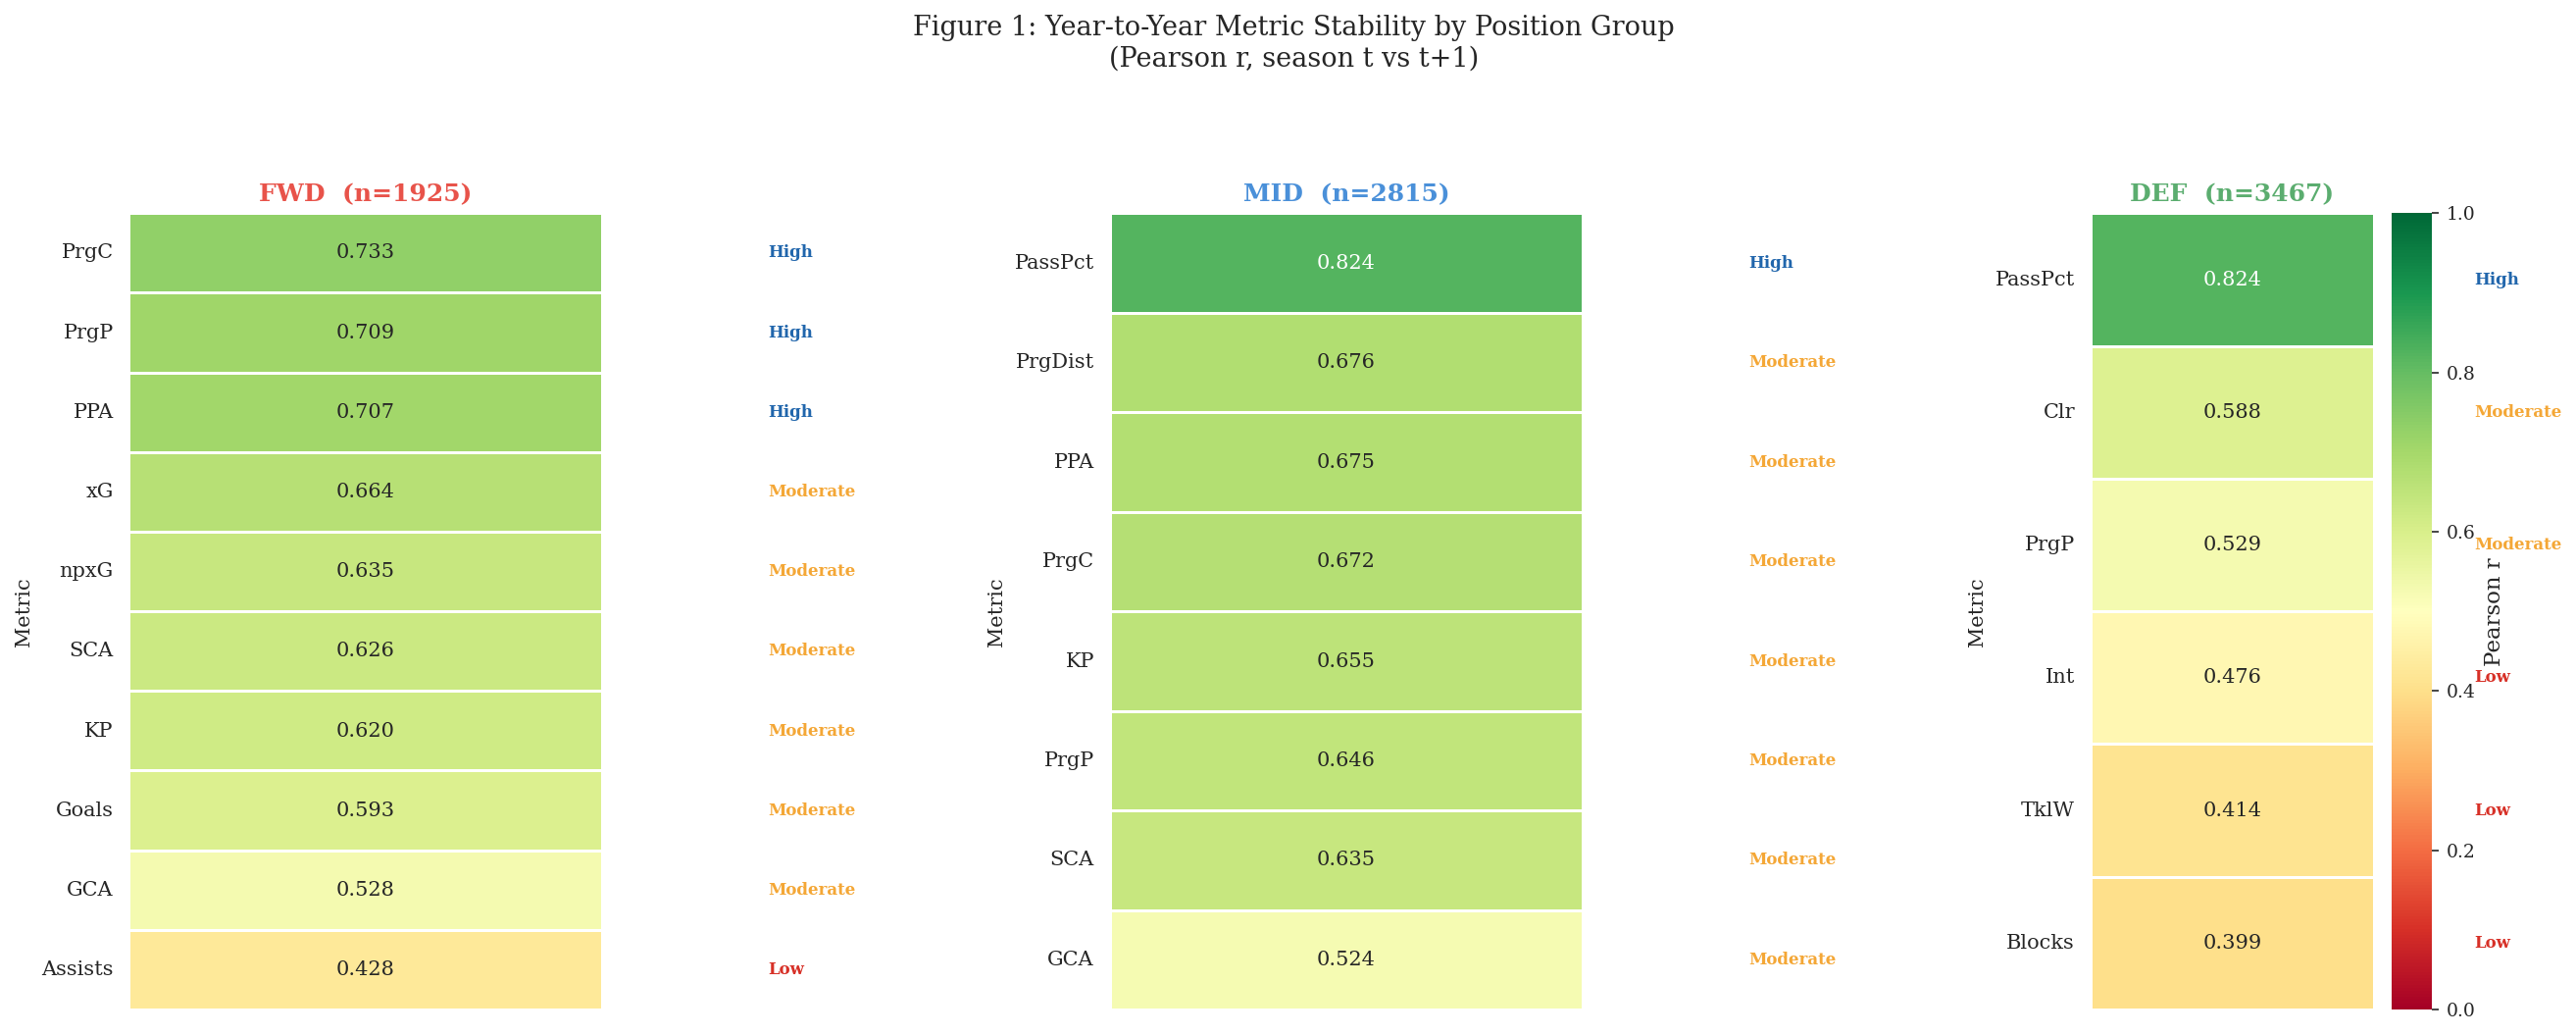

In [5]:
# ============================================================================
# CELL 5: FIGURE 1 — STABILITY HEATMAP
# ============================================================================

plt.rcParams.update(PUB_STYLE)

fig, axes = plt.subplots(1, 3, figsize=(18, 7),
                          gridspec_kw={'width_ratios': [8, 8, 6]})
fig.suptitle('Figure 1: Year-to-Year Metric Stability by Position Group\n(Pearson r, season t vs t+1)',
             fontsize=13, y=1.02)

for ax, pos in zip(axes, POS_BUCKETS):
    df_pos = (
        df_stability[df_stability['Pos'] == pos]
        .sort_values('Pearson_r', ascending=False)
        .set_index('Metric')[['Pearson_r']]
    )

    sns.heatmap(
        df_pos,
        ax=ax,
        vmin=0, vmax=1,
        cmap='RdYlGn',
        annot=True,
        fmt='.3f',
        linewidths=0.5,
        annot_kws={'size': 10},
        cbar=ax == axes[-1],
        cbar_kws={'label': 'Pearson r'} if ax == axes[-1] else {},
    )

    # Annotate stability label
    stab_map = df_stability[df_stability['Pos'] == pos].set_index('Metric')['Stability']
    for i, metric in enumerate(df_pos.index):
        label  = stab_map.get(metric, '')
        colour = STAB_COLOURS.get(label, 'black')
        ax.text(1.35, i + 0.5, label,
                transform=ax.get_yaxis_transform(),
                va='center', ha='left', fontsize=8,
                color=colour, fontweight='bold')

    ax.set_title(f'{pos}  (n={int(df_stability[df_stability["Pos"]==pos]["N"].iloc[0])})',
                 fontsize=12, color=POS_COLOURS[pos], fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Metric', fontsize=10)
    ax.tick_params(axis='x', labelbottom=False)
    ax.tick_params(axis='y', labelsize=10, pad=4)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout(pad=2.0, w_pad=3.0)
save_fig('fig1_stability_heatmap', fig)
plt.show()

Saved: fig2A_scatter_fwd.pdf / .png


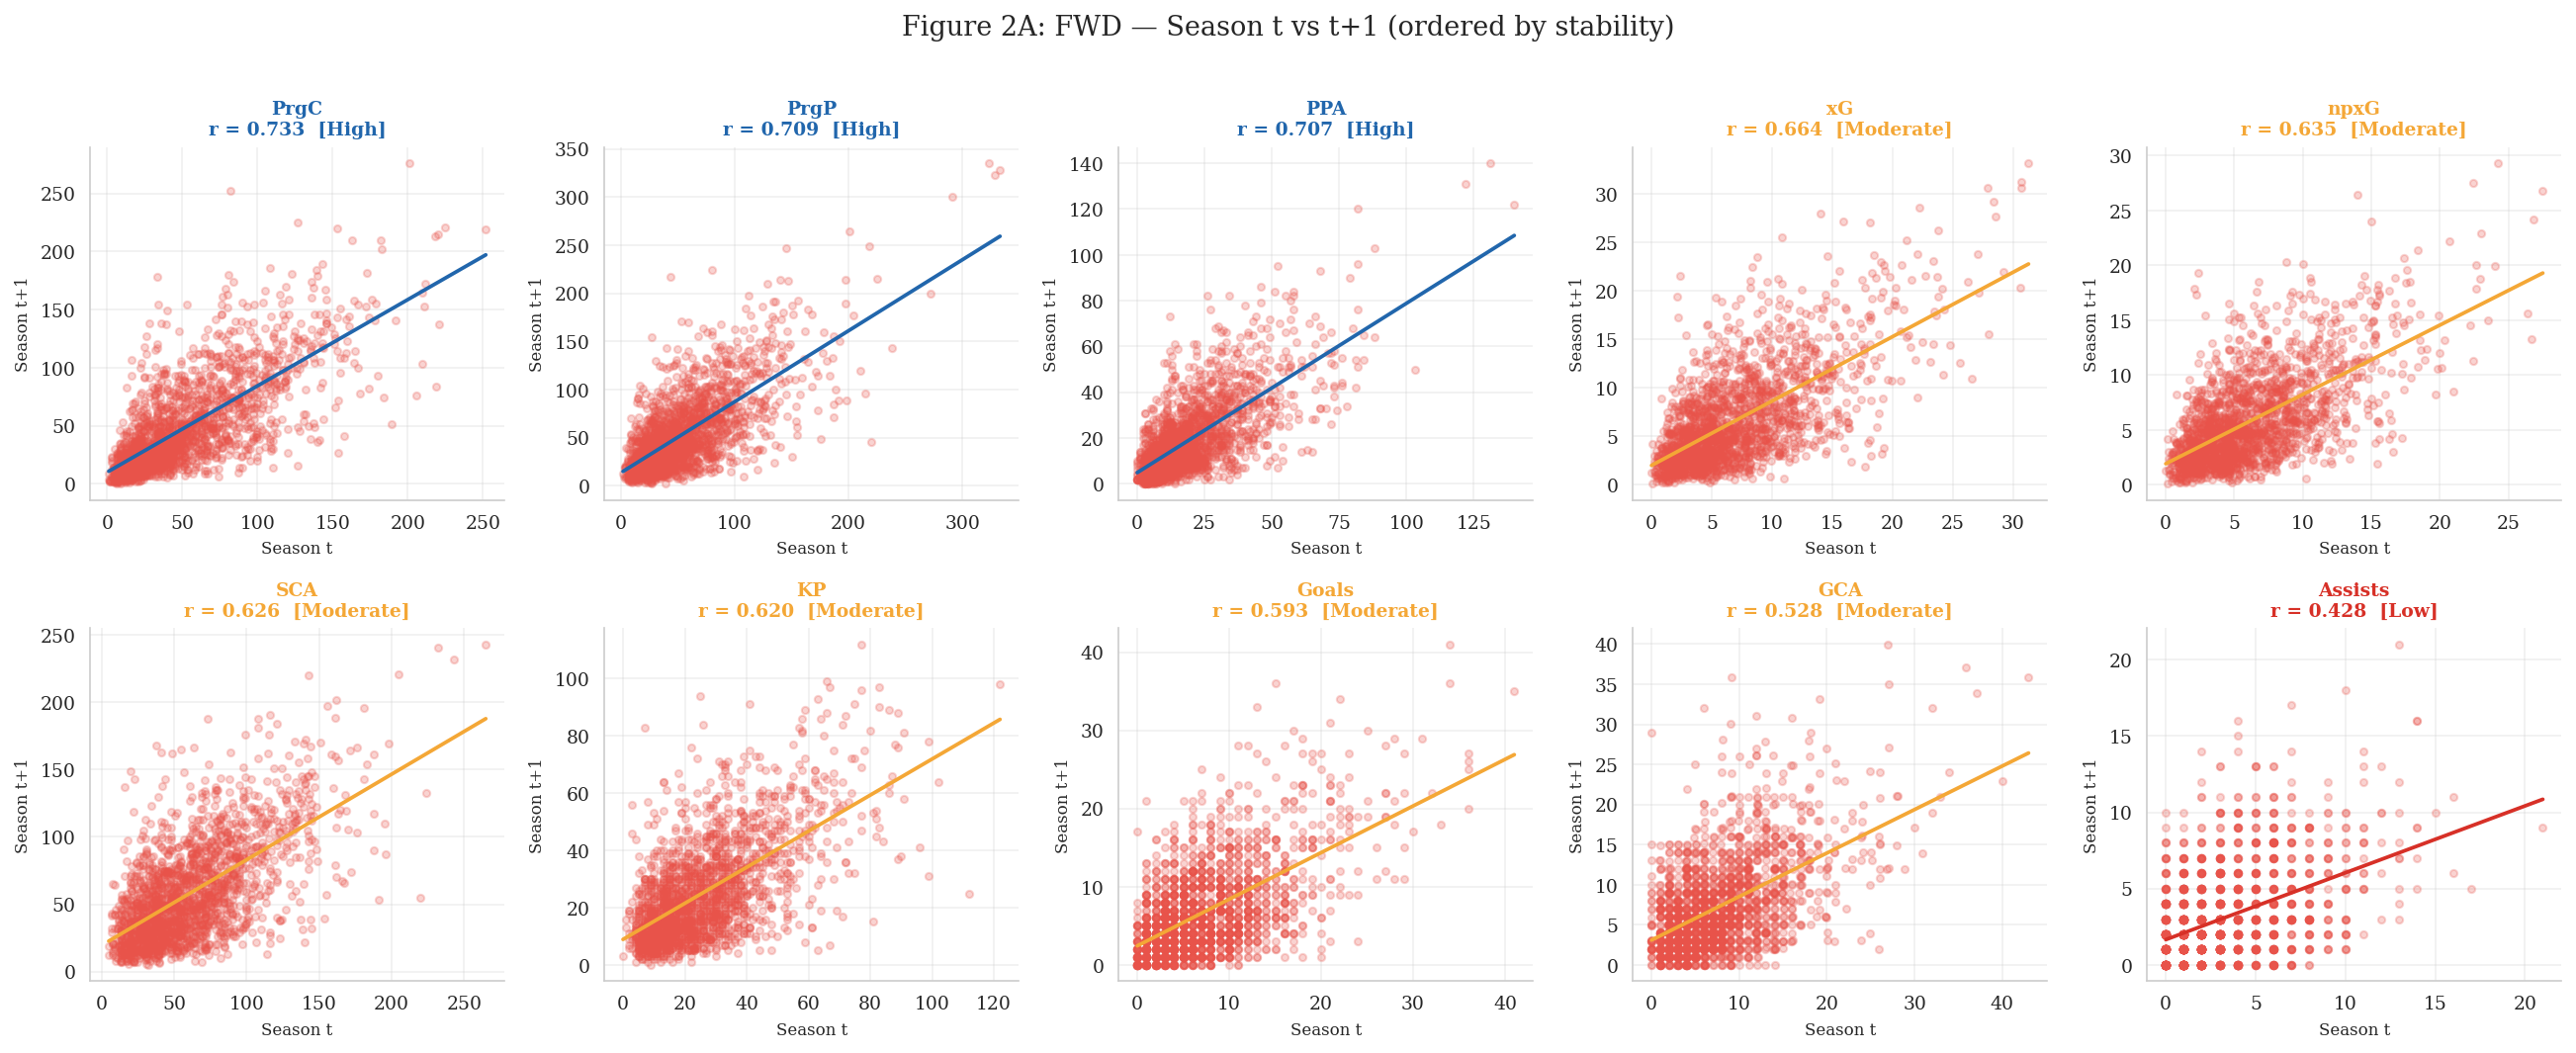

Saved: fig2B_scatter_mid.pdf / .png


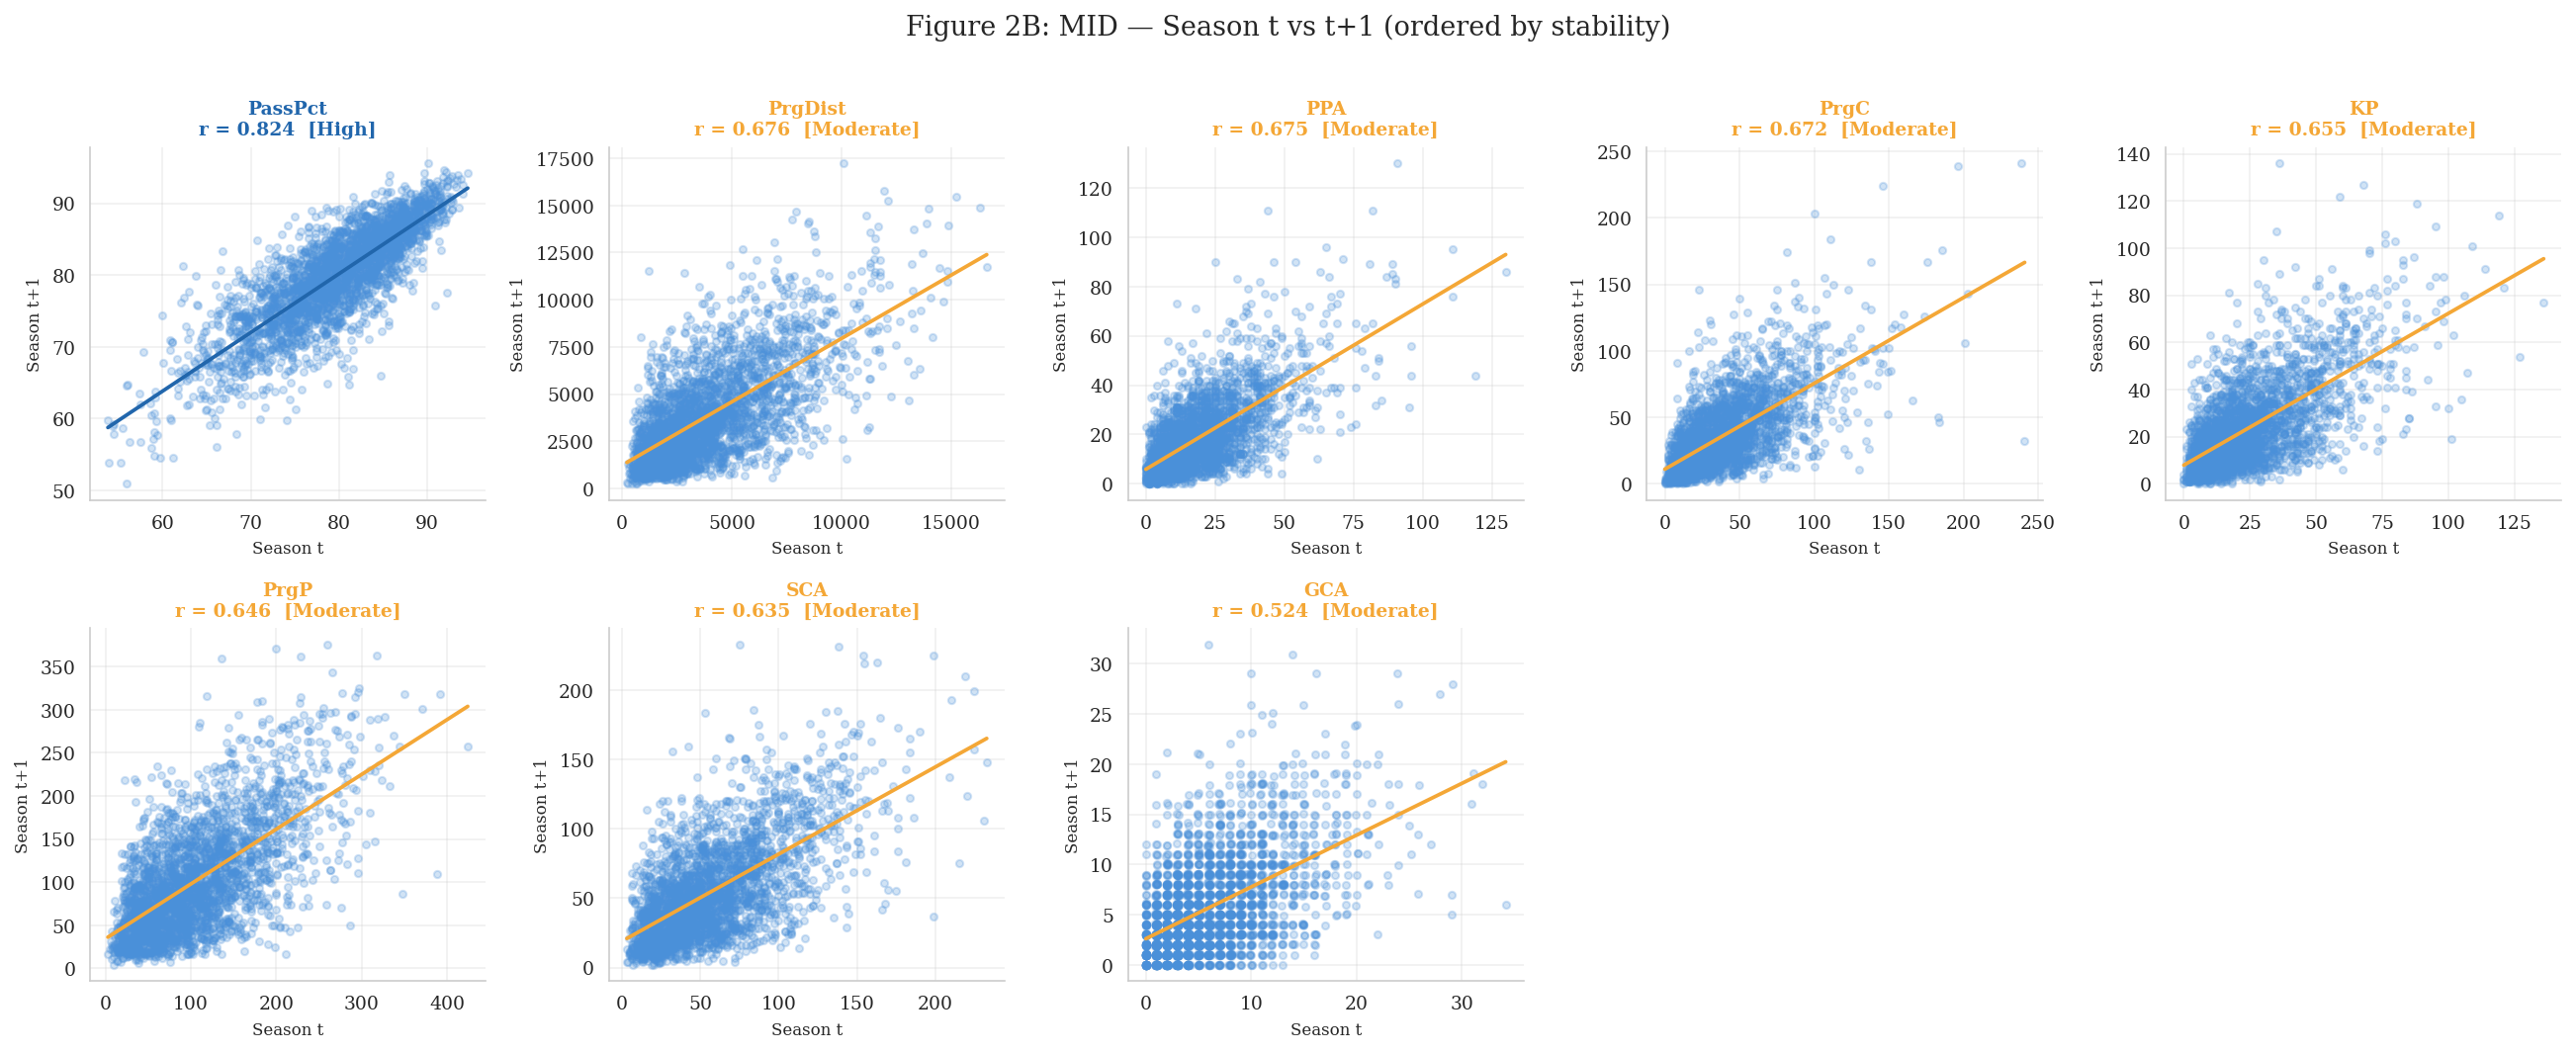

Saved: fig2C_scatter_def.pdf / .png


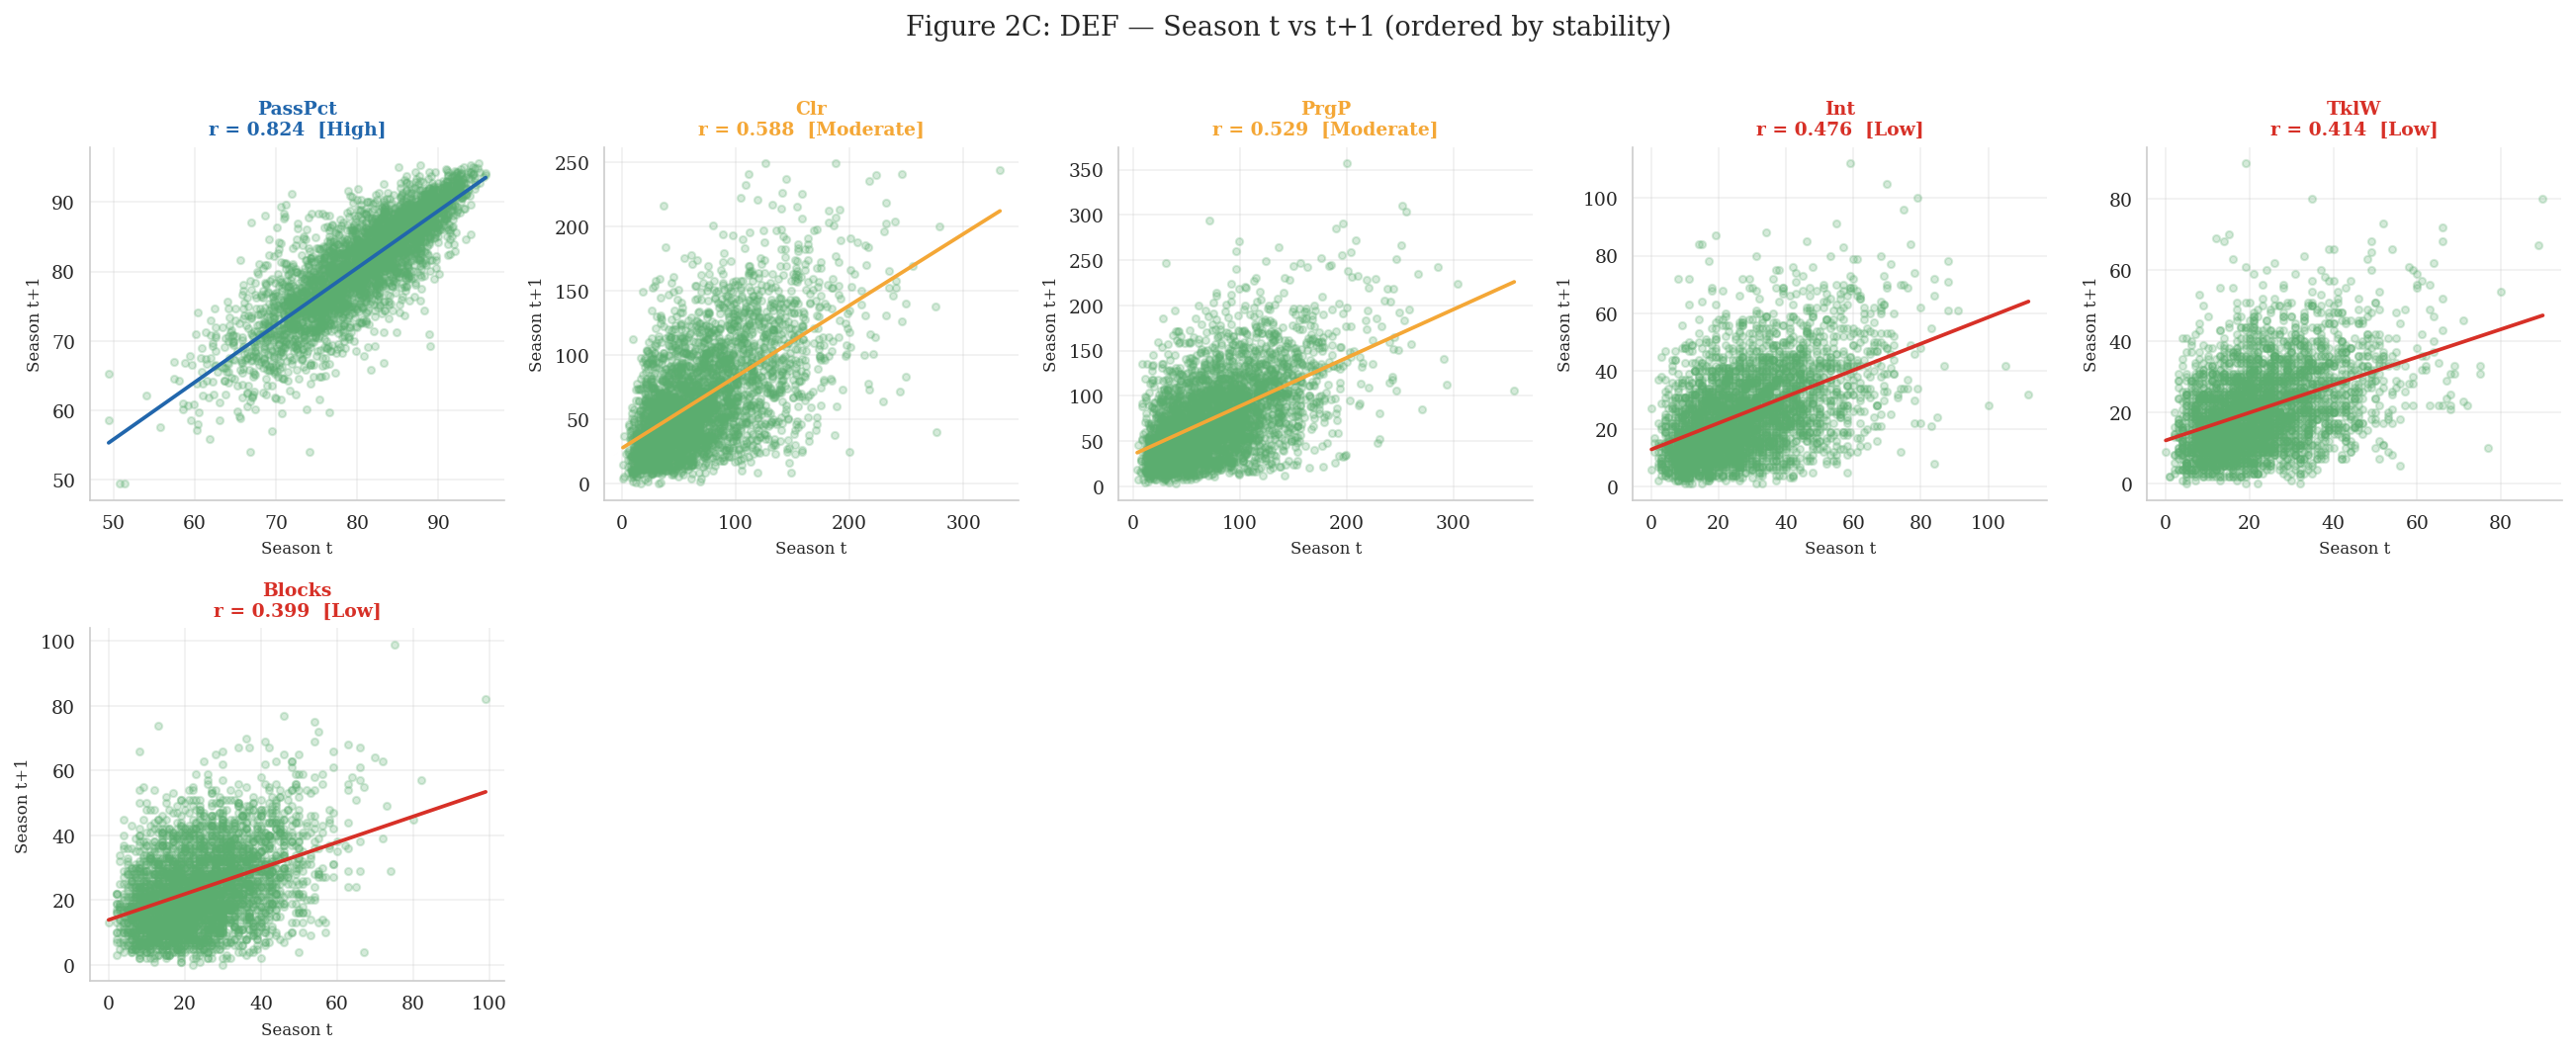

In [6]:
# ============================================================================
# CELL 6: FIGURE 2 — SCATTER PLOTS (season t vs t+1)
# ============================================================================
# One scatter per position × metric, arranged by position group.
# Shows the raw year-to-year relationship with regression line.
# Panels ordered by stability rank. Paper Figure 2.

plt.rcParams.update(PUB_STYLE)

for pos in POS_BUCKETS:
    stats_list = POS_STATS_MAP[pos]
    df_pos     = panel[panel['Pos_Bucket_t'] == pos].copy()

    # Order by stability rank
    order = (
        df_stability[df_stability['Pos'] == pos]
        .sort_values('Pearson_r', ascending=False)['Metric']
        .tolist()
    )

    ncols = 5
    nrows = int(np.ceil(len(order) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
    axes = np.array(axes).flatten()

    fig.suptitle(f'Figure 2{["A","B","C"][POS_BUCKETS.index(pos)]}: '
                 f'{pos} — Season t vs t+1 (ordered by stability)',
                 fontsize=13, y=1.01)

    for i, metric in enumerate(order):
        ax  = axes[i]
        col_t  = f'{metric}_t'
        col_t1 = f'{metric}_t1'

        if col_t not in df_pos.columns:
            ax.set_visible(False)
            continue

        x = df_pos[col_t].dropna()
        y = df_pos[col_t1].dropna()
        idx = df_pos[[col_t, col_t1]].dropna().index
        xv  = df_pos.loc[idx, col_t].values
        yv  = df_pos.loc[idx, col_t1].values

        row_stab = df_stability[(df_stability['Pos'] == pos) & (df_stability['Metric'] == metric)]
        r_val  = row_stab['Pearson_r'].values[0] if len(row_stab) else np.nan
        label  = row_stab['Stability'].values[0] if len(row_stab) else ''
        colour = STAB_COLOURS.get(label, 'grey')

        ax.scatter(xv, yv, alpha=0.25, s=12, color=POS_COLOURS[pos], rasterized=True)

        # Regression line
        if len(xv) > 10:
            m, b = np.polyfit(xv, yv, 1)
            x_line = np.linspace(xv.min(), xv.max(), 100)
            ax.plot(x_line, m * x_line + b, color=colour, lw=1.8, zorder=5)

        ax.set_title(f'{metric}\nr = {r_val:.3f}  [{label}]',
                     fontsize=9, color=colour, fontweight='bold')
        ax.set_xlabel('Season t',   fontsize=8)
        ax.set_ylabel('Season t+1', fontsize=8)
        ax.grid(alpha=0.3)

    # Hide unused panels
    for j in range(len(order), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    save_fig(f'fig2{["A","B","C"][POS_BUCKETS.index(pos)]}_scatter_{pos.lower()}', fig)
    plt.show()

Overlapping metrics (appear in >1 position group):
  GCA       : ['FWD', 'MID']
  KP        : ['FWD', 'MID']
  PPA       : ['FWD', 'MID']
  PassPct   : ['MID', 'DEF']
  PrgC      : ['FWD', 'MID']
  PrgP      : ['FWD', 'MID', 'DEF']
  SCA       : ['FWD', 'MID']
Saved: fig3_overlap_comparison.pdf / .png


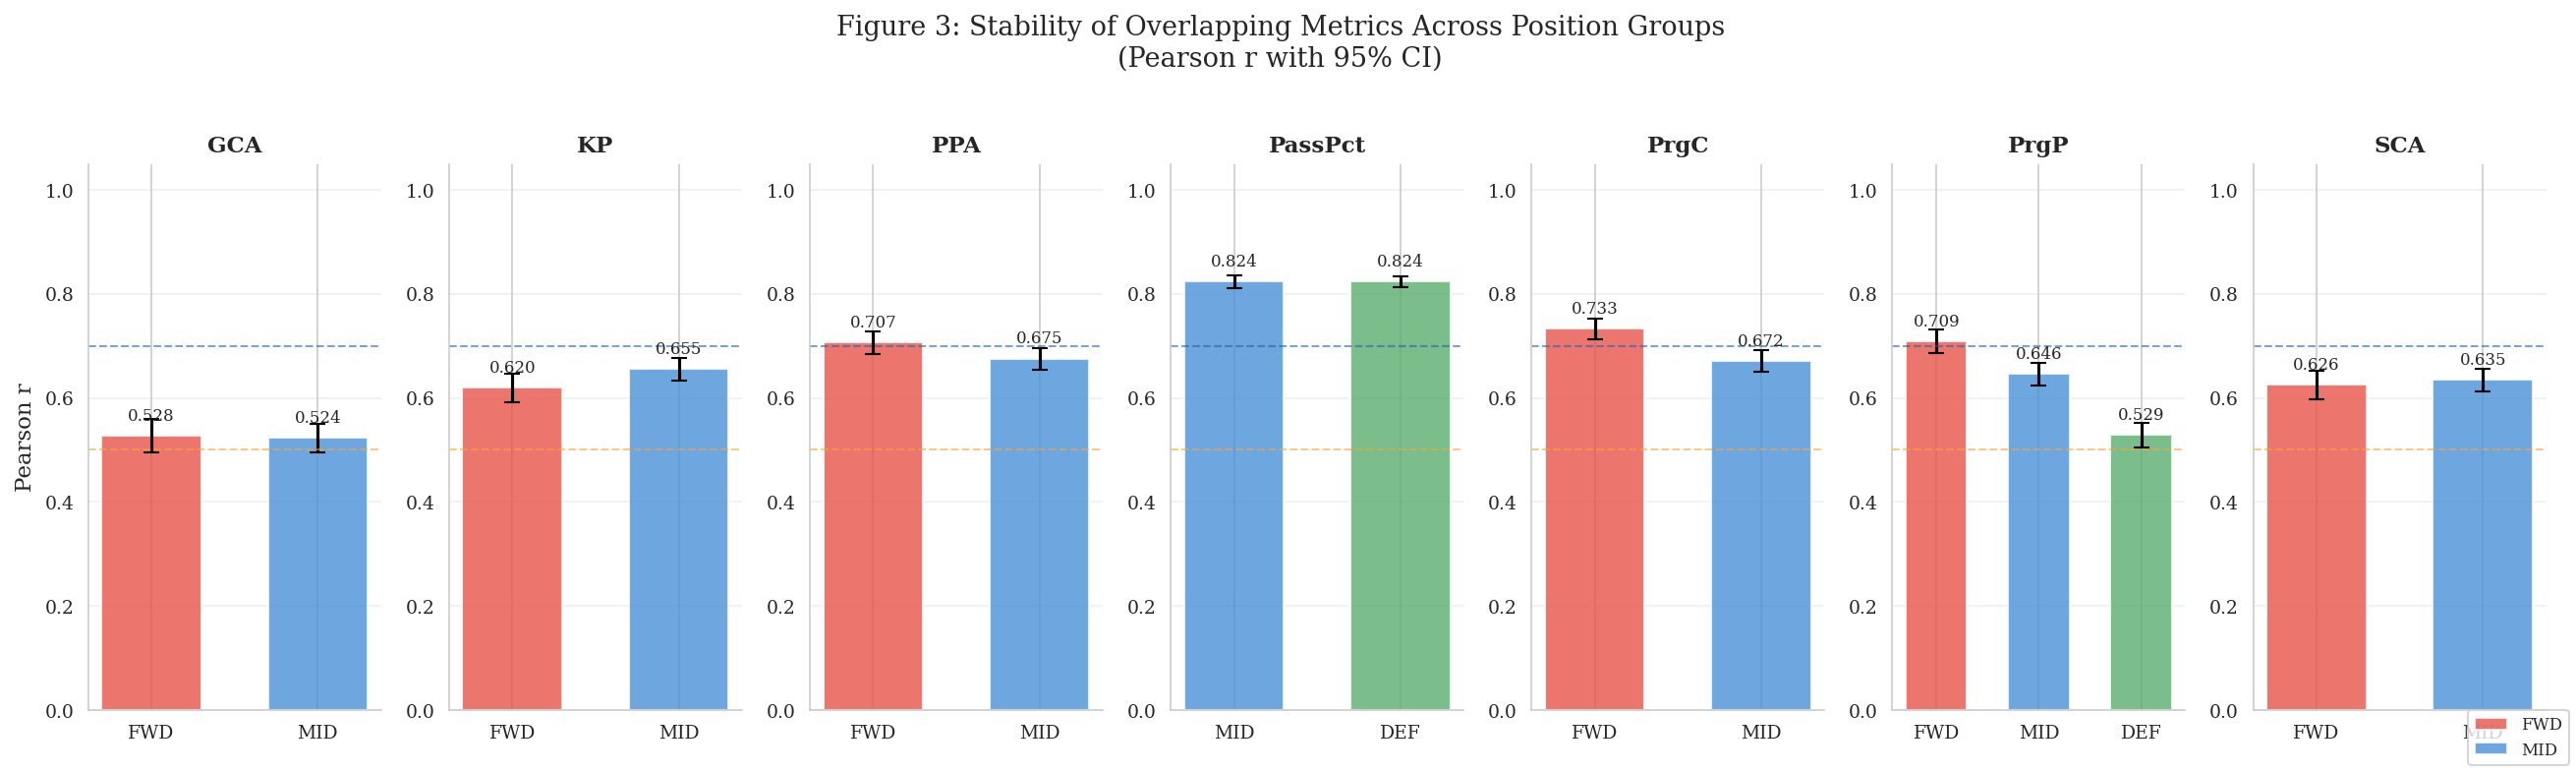

In [7]:
# ============================================================================
# CELL 7: FIGURE 3 — POSITION COMPARISON FOR OVERLAPPING METRICS
# ============================================================================
# For metrics that appear in more than one position group,
# compare stability side by side. Paper Figure 3.

plt.rcParams.update(PUB_STYLE)

# Find overlapping metrics
all_metric_pos = {}
for pos, stats_list in POS_STATS_MAP.items():
    for m in stats_list:
        all_metric_pos.setdefault(m, []).append(pos)

overlapping = {m: pos_list for m, pos_list in all_metric_pos.items() if len(pos_list) > 1}

print("Overlapping metrics (appear in >1 position group):")
for m, pos_list in sorted(overlapping.items()):
    print(f"  {m:<10}: {pos_list}")

fig, axes = plt.subplots(1, len(overlapping), figsize=(len(overlapping) * 2.5, 5))
fig.suptitle('Figure 3: Stability of Overlapping Metrics Across Position Groups\n(Pearson r with 95% CI)',
             fontsize=13, y=1.02)

for ax, (metric, pos_list) in zip(axes, sorted(overlapping.items())):
    df_m = df_stability[df_stability['Metric'] == metric].set_index('Pos')

    for i, pos in enumerate(pos_list):
        if pos not in df_m.index:
            continue
        row   = df_m.loc[pos]
        color = POS_COLOURS[pos]
        ax.bar(i, row['Pearson_r'], color=color, alpha=0.8, width=0.6, label=pos)
        ax.errorbar(i, row['Pearson_r'],
                    yerr=[[row['Pearson_r'] - row['CI_lo']],
                           [row['CI_hi'] - row['Pearson_r']]],
                    fmt='none', color='black', capsize=4, lw=1.5)
        ax.text(i, row['Pearson_r'] + 0.03, f"{row['Pearson_r']:.3f}",
                ha='center', fontsize=8)

    ax.axhline(THRESH_HIGH, color='#2166AC', linestyle='--', lw=1, alpha=0.6, label=f'High ({THRESH_HIGH})')
    ax.axhline(THRESH_MOD,  color='#F4A736', linestyle='--', lw=1, alpha=0.6, label=f'Mod ({THRESH_MOD})')
    ax.set_ylim(0, 1.05)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(pos_list)))
    ax.set_xticklabels(pos_list)
    ax.set_ylabel('Pearson r' if ax == axes[0] else '')
    ax.grid(axis='y', alpha=0.3)

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles[-2:], labels[-2:], loc='lower right', fontsize=8)
plt.tight_layout()
save_fig('fig3_overlap_comparison', fig)
plt.show()

In [8]:
# ============================================================================
# CELL 8: EXTENSION A — STABILITY BY AGE GROUP
# ============================================================================
# Does stability differ between young, prime, and veteran players?
# Computed separately per position × metric × age group.

print("=" * 75)
print("EXTENSION A: STABILITY BY AGE GROUP")
print("=" * 75 + "\n")

age_rows = []

for pos in POS_BUCKETS:
    stats_list = POS_STATS_MAP[pos]
    df_pos     = panel[panel['Pos_Bucket_t'] == pos].copy()

    for age_grp in AGE_GROUPS:
        df_age = df_pos[df_pos['Age_Group'] == age_grp]

        for metric in stats_list:
            col_t  = f'{metric}_t'
            col_t1 = f'{metric}_t1'
            if col_t not in df_age.columns:
                continue

            x = df_age[col_t].values.astype(float)
            y = df_age[col_t1].values.astype(float)
            r, ci_lo, ci_hi, n = pearson_with_ci(x, y)

            age_rows.append({
                'Pos': pos, 'Metric': metric, 'Age_Group': age_grp,
                'N': n, 'Pearson_r': round(r, 4) if not pd.isna(r) else np.nan,
                'CI_lo': round(ci_lo, 4) if not pd.isna(ci_lo) else np.nan,
                'CI_hi': round(ci_hi, 4) if not pd.isna(ci_hi) else np.nan,
            })

df_age_stability = pd.DataFrame(age_rows)

# Print summary table
for pos in POS_BUCKETS:
    print(f"\n  [{pos}]")
    print(f"  {'Metric':<10}", end='')
    for ag in AGE_GROUPS:
        print(f"  {ag[:12]:>14}", end='')
    print()
    print(f"  {'-'*65}")
    for metric in POS_STATS_MAP[pos]:
        print(f"  {metric:<10}", end='')
        for ag in AGE_GROUPS:
            row = df_age_stability[
                (df_age_stability['Pos'] == pos) &
                (df_age_stability['Metric'] == metric) &
                (df_age_stability['Age_Group'] == ag)
            ]
            if len(row) and not pd.isna(row['Pearson_r'].values[0]):
                print(f"  {row['Pearson_r'].values[0]:>14.3f}", end='')
            else:
                print(f"  {'—':>14}", end='')
        print()

print(f"\n✓ Age stability computed: {len(df_age_stability)} rows")

EXTENSION A: STABILITY BY AGE GROUP


  [FWD]
  Metric         Young (U23)    Prime (23-29    Veteran (30+
  -----------------------------------------------------------------
  KP                   0.592           0.602           0.725
  PrgP                 0.621           0.688           0.825
  PrgC                 0.678           0.738           0.828
  SCA                  0.590           0.603           0.761
  Goals                0.595           0.517           0.749
  Assists              0.459           0.363           0.550
  xG                   0.643           0.609           0.809
  npxG                 0.621           0.590           0.777
  GCA                  0.522           0.467           0.692
  PPA                  0.619           0.698           0.817

  [MID]
  Metric         Young (U23)    Prime (23-29    Veteran (30+
  -----------------------------------------------------------------
  KP                   0.521           0.676           0.733
  PrgP          

Saved: fig4_stability_by_age.pdf / .png


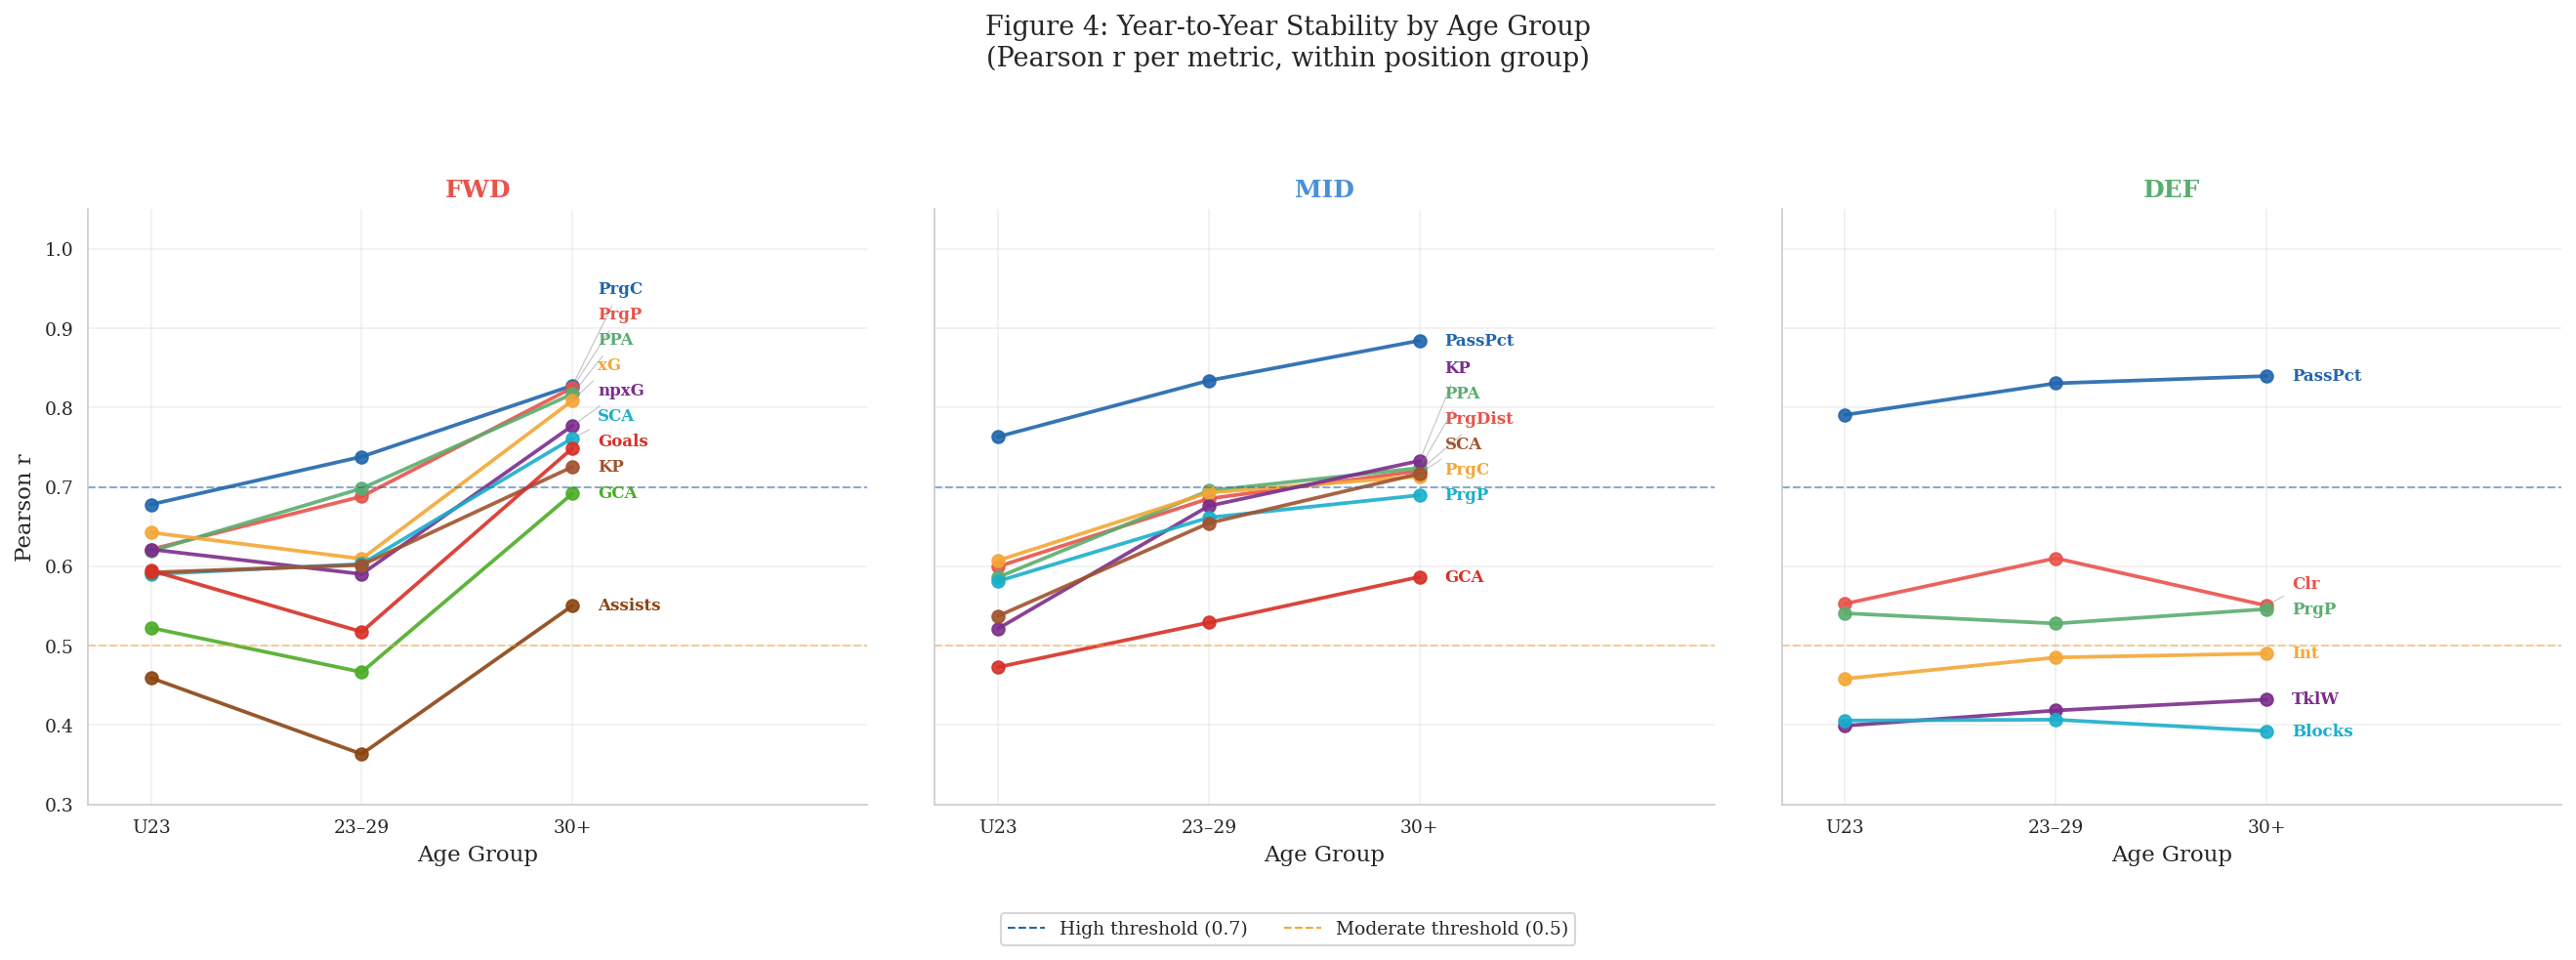

In [22]:
# ============================================================================
# CELL 8b: FIGURE 4 — STABILITY BY AGE GROUP
# ============================================================================

plt.rcParams.update(PUB_STYLE)

AGE_ORDER  = ['Young (U23)', 'Prime (23-29)', 'Veteran (30+)']
AGE_LABELS = ['U23', '23–29', '30+']

METRIC_COLOURS = [
    '#2166AC',  # dark blue
    '#E8534A',  # red
    '#5BAD6F',  # green
    '#F4A736',  # orange
    '#7B2D8B',  # purple
    '#1AAECC',  # teal
    '#A0522D',  # brown
    '#D73027',  # dark red
    '#4DAC26',  # lime green
    '#8B4513',  # saddle brown
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Figure 4: Year-to-Year Stability by Age Group\n'
             '(Pearson r per metric, within position group)',
             fontsize=13, y=1.02)

def place_labels_no_overlap(label_data, min_gap=0.032):
    if not label_data:
        return []
    sorted_data = sorted(label_data, key=lambda x: x[0])
    adjusted = [list(item) for item in sorted_data]
    for i in range(1, len(adjusted)):
        if adjusted[i][0] - adjusted[i-1][0] < min_gap:
            adjusted[i][0] = adjusted[i-1][0] + min_gap
    for i in range(len(adjusted) - 2, -1, -1):
        if adjusted[i+1][0] - adjusted[i][0] < min_gap:
            adjusted[i][0] = adjusted[i+1][0] - min_gap
    return adjusted

for ax, pos in zip(axes, POS_BUCKETS):
    df_pos = df_age_stability[df_age_stability['Pos'] == pos]

    # Sort metrics by overall stability rank
    order = (df_stability[df_stability['Pos'] == pos]
             .sort_values('Pearson_r', ascending=False)['Metric'].tolist())

    label_data = []

    for idx, metric in enumerate(order):
        df_m   = df_pos[df_pos['Metric'] == metric].set_index('Age_Group')
        y_vals = [df_m.loc[ag, 'Pearson_r'] if ag in df_m.index else np.nan
                  for ag in AGE_ORDER]

        colour = METRIC_COLOURS[idx % len(METRIC_COLOURS)]

        ax.plot(AGE_LABELS, y_vals, marker='o', lw=1.8,
                color=colour, alpha=0.9)

        if not np.isnan(y_vals[-1]):
            label_data.append((y_vals[-1], metric, colour, y_vals[-1]))

    # Place labels with no-overlap adjustment
    raw    = [(d[0], d[1], d[2]) for d in label_data]
    placed = place_labels_no_overlap(raw, min_gap=0.032)

    for (y_adj, metric, colour), (_, _, _, y_true) in zip(
            placed, sorted(label_data, key=lambda x: x[0])):
        ax.annotate(
            metric,
            xy=(2, y_true),
            xytext=(2.12, y_adj),
            fontsize=8,
            color=colour,
            fontweight='bold',
            va='center',
            arrowprops=dict(
                arrowstyle='-',
                color='grey',
                lw=0.5,
                alpha=0.5,
            ) if abs(y_adj - y_true) > 0.01 else None,
        )

    ax.axhline(THRESH_HIGH, color='#2166AC', linestyle='--', lw=1, alpha=0.5)
    ax.axhline(THRESH_MOD,  color='#F4A736', linestyle='--', lw=1, alpha=0.5)
    ax.set_ylim(0.3, 1.05)
    ax.set_xlim(-0.3, 3.4)
    ax.set_title(f'{pos}', fontsize=12, color=POS_COLOURS[pos], fontweight='bold')
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Pearson r' if ax == axes[0] else '')
    ax.grid(alpha=0.3)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#2166AC', linestyle='--', lw=1,
           label=f'High threshold ({THRESH_HIGH})'),
    Line2D([0], [0], color='#F4A736', linestyle='--', lw=1,
           label=f'Moderate threshold ({THRESH_MOD})'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=9, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(pad=2.0, w_pad=3.0)
save_fig('fig4_stability_by_age', fig)
plt.show()

In [10]:
# ============================================================================
# CELL 9: EXTENSION B — STABILITY BY LEAGUE
# ============================================================================
# Are metrics equally stable across the Big Five leagues?

print("=" * 75)
print("EXTENSION B: STABILITY BY LEAGUE")
print("=" * 75 + "\n")

league_rows = []

for pos in POS_BUCKETS:
    stats_list = POS_STATS_MAP[pos]
    df_pos     = panel[panel['Pos_Bucket_t'] == pos].copy()

    for league in VALID_LEAGUES:
        df_lg = df_pos[df_pos['Comp_t'] == league]

        for metric in stats_list:
            col_t  = f'{metric}_t'
            col_t1 = f'{metric}_t1'
            if col_t not in df_lg.columns:
                continue

            x = df_lg[col_t].values.astype(float)
            y = df_lg[col_t1].values.astype(float)
            r, ci_lo, ci_hi, n = pearson_with_ci(x, y)

            league_rows.append({
                'Pos': pos, 'Metric': metric, 'League': league,
                'N': n, 'Pearson_r': round(r, 4) if not pd.isna(r) else np.nan,
            })

df_league_stability = pd.DataFrame(league_rows)

# Print summary
for pos in POS_BUCKETS:
    print(f"\n  [{pos}]")
    print(f"  {'Metric':<10}", end='')
    for lg in VALID_LEAGUES:
        print(f"  {lg[:10]:>12}", end='')
    print()
    print(f"  {'-'*75}")
    for metric in POS_STATS_MAP[pos]:
        print(f"  {metric:<10}", end='')
        for lg in VALID_LEAGUES:
            row = df_league_stability[
                (df_league_stability['Pos'] == pos) &
                (df_league_stability['Metric'] == metric) &
                (df_league_stability['League'] == lg)
            ]
            if len(row) and not pd.isna(row['Pearson_r'].values[0]):
                print(f"  {row['Pearson_r'].values[0]:>12.3f}", end='')
            else:
                print(f"  {'—':>12}", end='')
        print()

print(f"\n✓ League stability computed: {len(df_league_stability)} rows")

EXTENSION B: STABILITY BY LEAGUE


  [FWD]
  Metric        Premier Le       Ligue 1    Bundesliga       Serie A       La Liga
  ---------------------------------------------------------------------------
  KP                 0.595         0.614         0.539         0.610         0.694
  PrgP               0.709         0.669         0.629         0.704         0.782
  PrgC               0.712         0.703         0.705         0.693         0.810
  SCA                0.611         0.596         0.537         0.609         0.711
  Goals              0.594         0.592         0.560         0.576         0.633
  Assists            0.387         0.502         0.340         0.410         0.468
  xG                 0.650         0.624         0.659         0.702         0.673
  npxG               0.617         0.616         0.621         0.674         0.631
  GCA                0.483         0.539         0.433         0.509         0.631
  PPA                0.680         0.694         

Saved: fig5_stability_by_league.pdf / .png


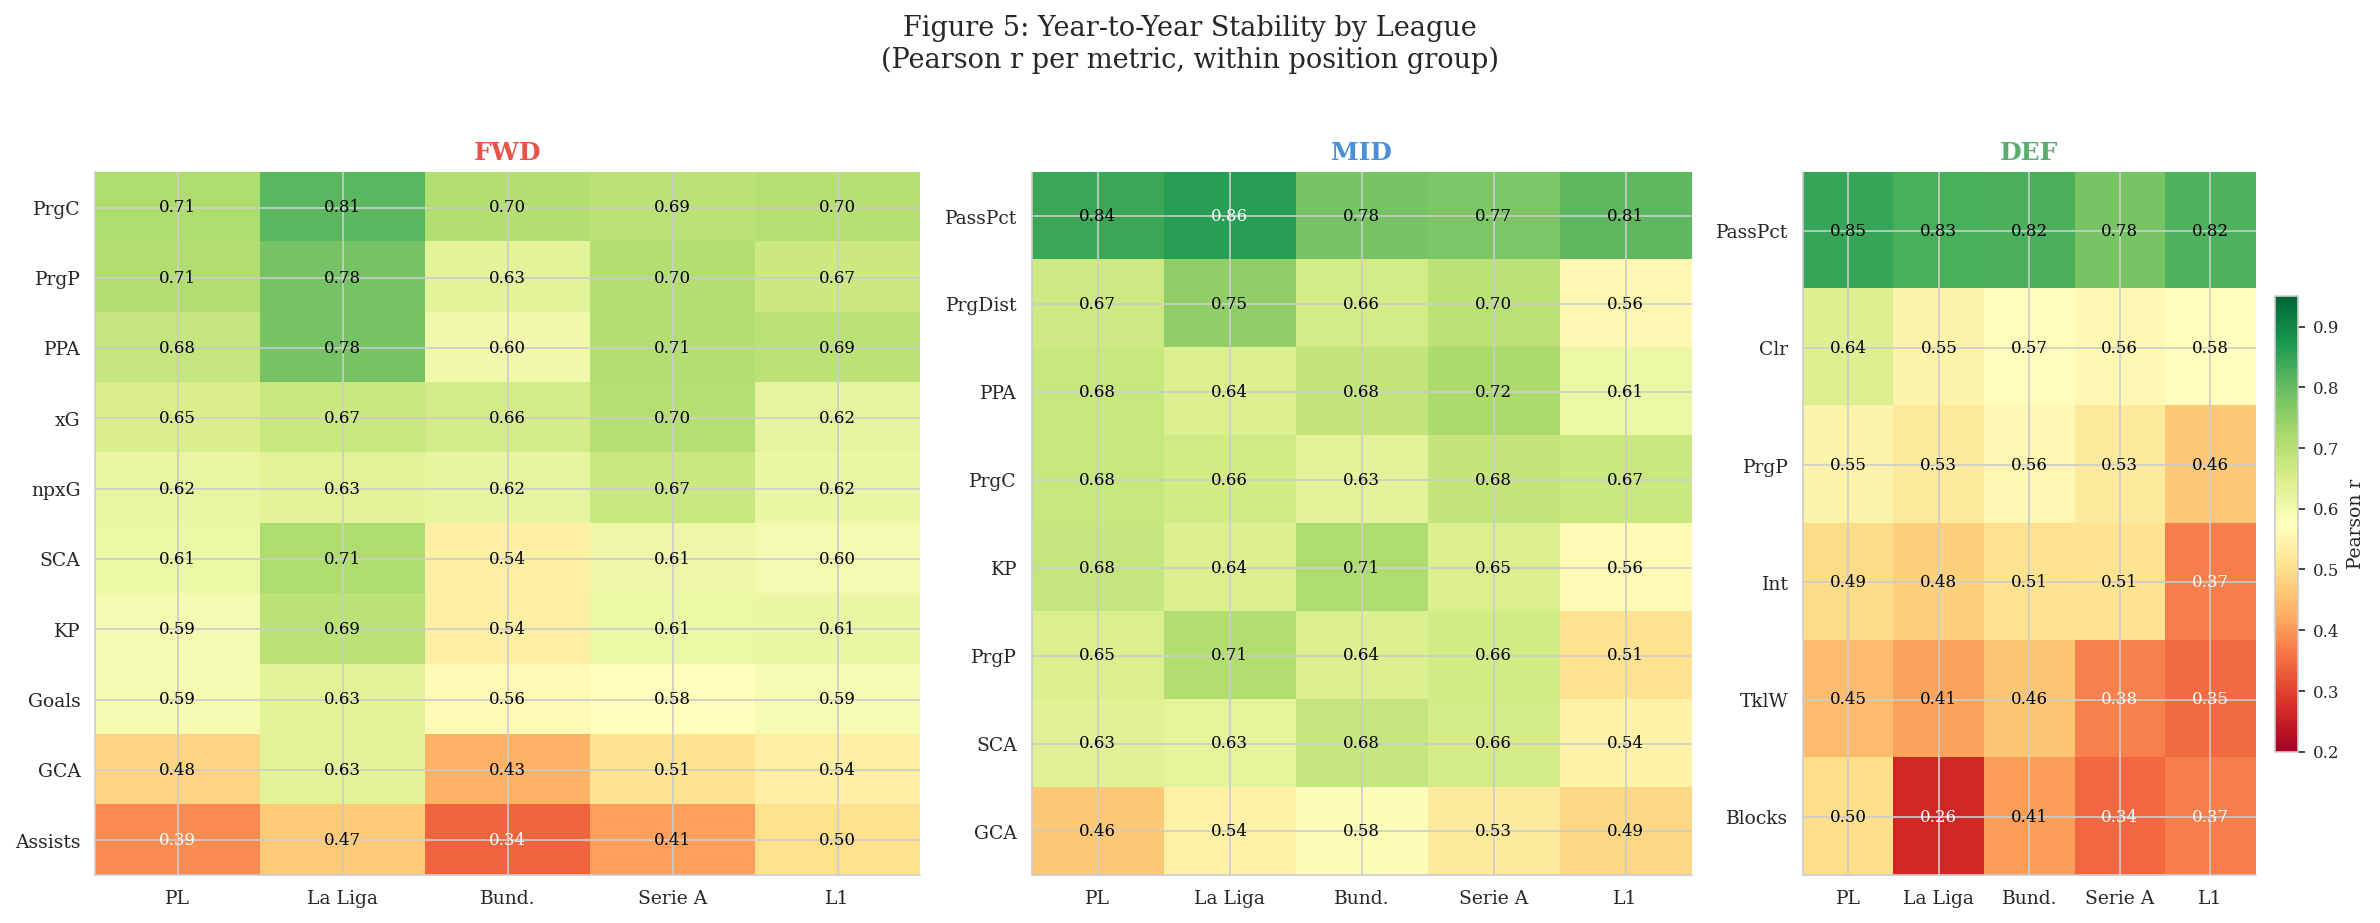

In [11]:
# ============================================================================
# CELL 9b: FIGURE 5 — STABILITY BY LEAGUE
# ============================================================================
# Heatmap: rows = metrics, columns = leagues, cells = Pearson r.
# Faceted by position group. Highlights Ligue 1 as least stable.

plt.rcParams.update(PUB_STYLE)

LEAGUE_ORDER  = ['Premier League', 'La Liga', 'Bundesliga', 'Serie A', 'Ligue 1']
LEAGUE_LABELS = ['PL', 'La Liga', 'Bund.', 'Serie A', 'L1']

fig, axes = plt.subplots(1, 3, figsize=(16, 6),
                          gridspec_kw={'width_ratios': [10, 8, 6]})
fig.suptitle('Figure 5: Year-to-Year Stability by League\n(Pearson r per metric, within position group)',
             fontsize=13, y=1.02)

for ax, pos in zip(axes, POS_BUCKETS):
    stats_list = POS_STATS_MAP[pos]

    # Build matrix: rows = metrics (ranked by overall r), cols = leagues
    order = (df_stability[df_stability['Pos'] == pos]
             .sort_values('Pearson_r', ascending=False)['Metric'].tolist())

    matrix = np.full((len(order), len(LEAGUE_ORDER)), np.nan)
    for i, metric in enumerate(order):
        for j, league in enumerate(LEAGUE_ORDER):
            row = df_league_stability[
                (df_league_stability['Pos'] == pos) &
                (df_league_stability['Metric'] == metric) &
                (df_league_stability['League'] == league)
            ]
            if len(row):
                matrix[i, j] = row['Pearson_r'].values[0]

    im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0.2, vmax=0.95)

    # Annotate cells
    for i in range(len(order)):
        for j in range(len(LEAGUE_ORDER)):
            val = matrix[i, j]
            if not np.isnan(val):
                text_col = 'white' if val < 0.4 or val > 0.85 else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=8, color=text_col)

    ax.set_xticks(range(len(LEAGUE_ORDER)))
    ax.set_xticklabels(LEAGUE_LABELS, fontsize=9)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order, fontsize=9)
    ax.set_title(f'{pos}', fontsize=12, color=POS_COLOURS[pos], fontweight='bold')

    # Colourbar on last panel only
    if ax == axes[-1]:
        cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cb.set_label('Pearson r', fontsize=9)
        cb.ax.tick_params(labelsize=8)

plt.tight_layout()
save_fig('fig5_stability_by_league', fig)
plt.show()

In [12]:
# ============================================================================
# CELL 10: EXTENSION C — FISHER Z-TESTS ON AGE GROUP DIFFERENCES
# ============================================================================
# Formally tests whether stability differences between age groups are
# statistically significant using Fisher z-transformation comparison.
# Tests: Young vs Prime, Prime vs Veteran, Young vs Veteran (most important)
# ============================================================================

print("=" * 75)
print("EXTENSION C: FISHER Z-TESTS — AGE GROUP DIFFERENCES")
print("=" * 75)
print("\n  H0: r(age_group_1) = r(age_group_2)")
print("  Test: Two-sample Fisher z-test")
print("  Significance: p < 0.05 (*), p < 0.01 (**), p < 0.001 (***)\n")

def fisher_z_test(r1, n1, r2, n2):
    """
    Two-sample Fisher z-test for difference between two Pearson correlations.
    Returns z-statistic and two-tailed p-value.
    """
    if pd.isna(r1) or pd.isna(r2) or n1 < 10 or n2 < 10:
        return np.nan, np.nan
    z1   = np.arctanh(np.clip(r1, -0.9999, 0.9999))
    z2   = np.arctanh(np.clip(r2, -0.9999, 0.9999))
    se   = np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    z    = (z1 - z2) / se
    p    = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p

def sig_stars(p):
    if pd.isna(p):   return '—'
    if p < 0.001:    return '***'
    if p < 0.01:     return '**'
    if p < 0.05:     return '*'
    return 'ns'

AGE_COMPARISONS = [
    ('Young (U23)',    'Prime (23-29)'),
    ('Prime (23-29)', 'Veteran (30+)'),
    ('Young (U23)',   'Veteran (30+)'),   # key comparison
]

fisher_rows = []

for pos in POS_BUCKETS:
    print(f"\n  [{pos}]")
    print(f"  {'Metric':<10} {'Young vs Prime':>16} {'Prime vs Vet':>14} "
          f"{'Young vs Vet':>14} {'Sig (Y vs V)':>13}")
    print(f"  {'-'*70}")

    for metric in POS_STATS_MAP[pos]:
        row_out = f"  {metric:<10}"
        sig_yvv = ''

        for (ag1, ag2) in AGE_COMPARISONS:
            r1_row = df_age_stability[
                (df_age_stability['Pos'] == pos) &
                (df_age_stability['Metric'] == metric) &
                (df_age_stability['Age_Group'] == ag1)
            ]
            r2_row = df_age_stability[
                (df_age_stability['Pos'] == pos) &
                (df_age_stability['Metric'] == metric) &
                (df_age_stability['Age_Group'] == ag2)
            ]
            if not len(r1_row) or not len(r2_row):
                row_out += f"  {'—':>14}"
                continue

            r1, n1 = r1_row['Pearson_r'].values[0], r1_row['N'].values[0]
            r2, n2 = r2_row['Pearson_r'].values[0], r2_row['N'].values[0]
            z, p   = fisher_z_test(r1, n1, r2, n2)

            label = f"z={z:.2f} {sig_stars(p)}" if not pd.isna(z) else "—"
            row_out += f"  {label:>14}"

            fisher_rows.append({
                'Pos': pos, 'Metric': metric,
                'Group1': ag1, 'Group2': ag2,
                'r1': r1, 'n1': n1, 'r2': r2, 'n2': n2,
                'z_stat': round(z, 3) if not pd.isna(z) else np.nan,
                'p_value': round(p, 4) if not pd.isna(p) else np.nan,
                'sig': sig_stars(p),
            })

            if ag1 == 'Young (U23)' and ag2 == 'Veteran (30+)':
                sig_yvv = sig_stars(p)

        print(row_out + f"  {sig_yvv:>13}")

df_fisher = pd.DataFrame(fisher_rows)

# Summary: how many Young vs Veteran differences are significant?
yvv = df_fisher[
    (df_fisher['Group1'] == 'Young (U23)') &
    (df_fisher['Group2'] == 'Veteran (30+)')
]
n_sig = (yvv['p_value'] < 0.05).sum()
print(f"\n  Young vs Veteran: {n_sig}/{len(yvv)} metric-position combinations "
      f"significantly different (p < 0.05)")
print(f"\n✓ Fisher z-tests complete: {len(df_fisher)} comparisons")

EXTENSION C: FISHER Z-TESTS — AGE GROUP DIFFERENCES

  H0: r(age_group_1) = r(age_group_2)
  Test: Two-sample Fisher z-test
  Significance: p < 0.05 (*), p < 0.01 (**), p < 0.001 (***)


  [FWD]
  Metric       Young vs Prime   Prime vs Vet   Young vs Vet  Sig (Y vs V)
  ----------------------------------------------------------------------
  KP              z=-0.27 ns     z=-3.49 ***     z=-3.31 ***            ***
  PrgP             z=-2.18 *     z=-5.13 ***     z=-6.19 ***            ***
  PrgC             z=-2.25 *     z=-3.67 ***     z=-4.95 ***            ***
  SCA             z=-0.37 ns     z=-4.72 ***     z=-4.48 ***            ***
  Goals             z=2.09 *     z=-6.21 ***     z=-3.97 ***            ***
  Assists           z=2.15 *     z=-3.72 ***      z=-1.70 ns             ns
  xG               z=1.02 ns     z=-6.50 ***     z=-5.02 ***            ***
  npxG             z=0.91 ns     z=-5.63 ***     z=-4.33 ***            ***
  GCA              z=1.38 ns     z=-5.40 ***     z

SENSITIVITY ANALYSIS: MIN_90S THRESHOLD SWEEP

  Chosen threshold : MIN_90S = 5.0
  Sweep range      : 3.0 → 7.0 (step 0.5)

  MIN_90S=3.0  n= 8993  FWD=0.628  MID=0.654  DEF=0.541  mean=0.615  
  MIN_90S=3.5  n= 8802  FWD=0.625  MID=0.657  DEF=0.539  mean=0.614  
  MIN_90S=4.0  n= 8621  FWD=0.625  MID=0.658  DEF=0.536  mean=0.614  
  MIN_90S=4.5  n= 8408  FWD=0.625  MID=0.660  DEF=0.537  mean=0.614  
  MIN_90S=5.0  n= 8207  FWD=0.624  MID=0.663  DEF=0.538  mean=0.616  ← chosen
  MIN_90S=5.5  n= 8028  FWD=0.625  MID=0.660  DEF=0.538  mean=0.615  
  MIN_90S=6.0  n= 7829  FWD=0.627  MID=0.661  DEF=0.540  mean=0.617  
  MIN_90S=6.5  n= 7638  FWD=0.626  MID=0.663  DEF=0.544  mean=0.618  
  MIN_90S=7.0  n= 7443  FWD=0.628  MID=0.664  DEF=0.548  mean=0.620  

  Mean r range across sweep : 0.614 – 0.620 (Δ = 0.006)
  Mean r at chosen MIN_90S  : 0.616
  Verdict: ✓ Stable — results robust to threshold choice
Saved: fig7_min90s_sensitivity.pdf / .png


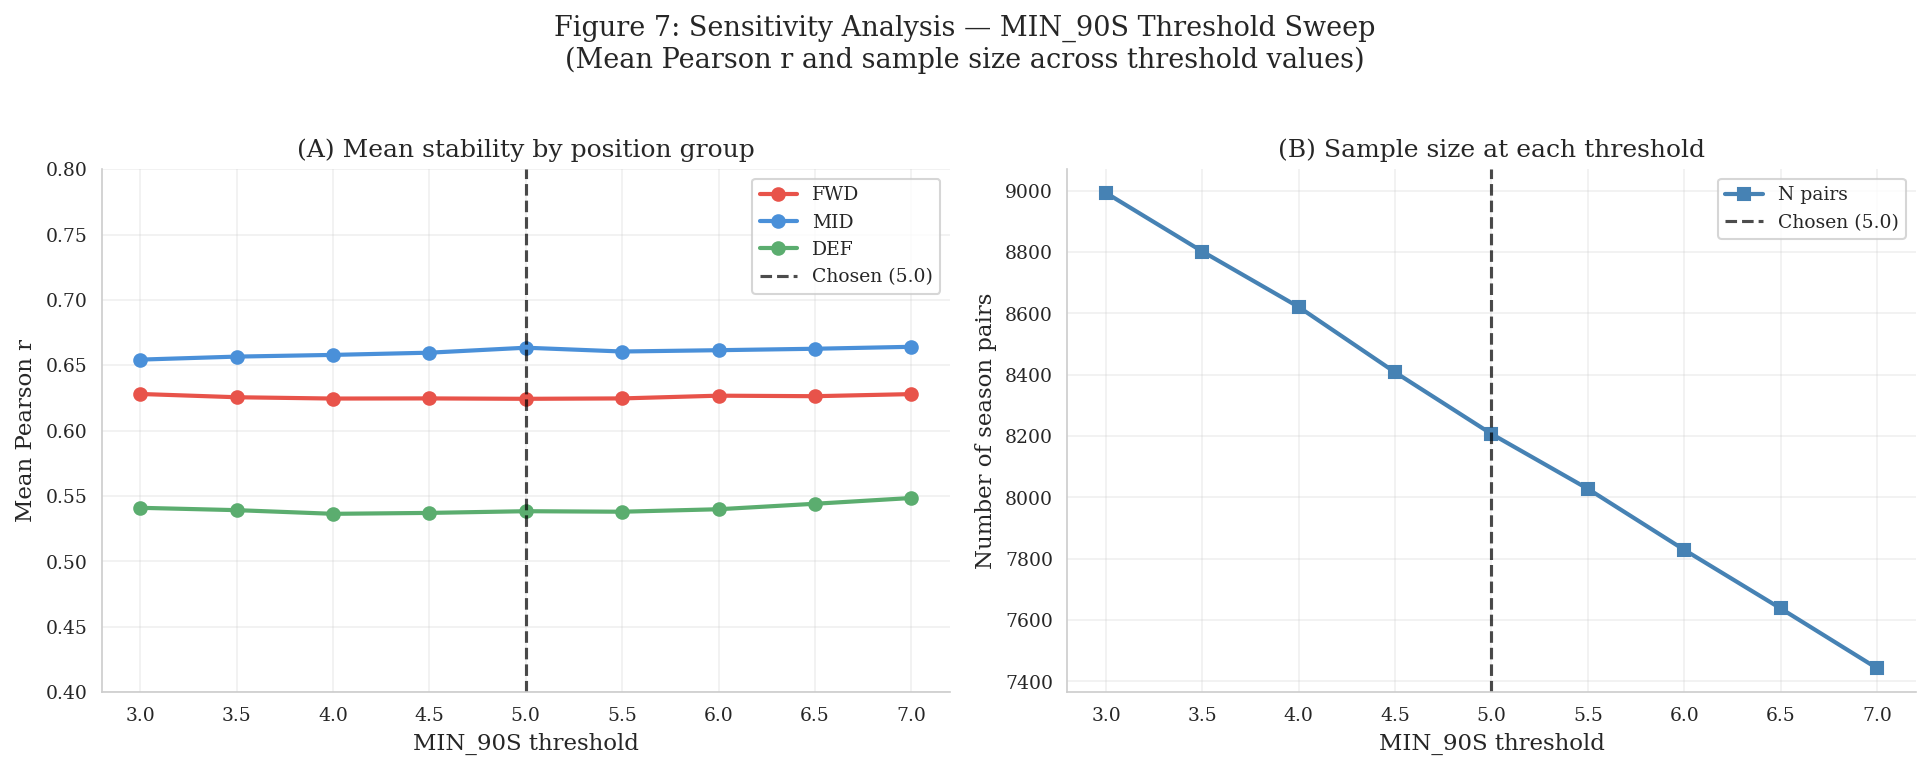


Saved: fig7_min90s_sensitivity.pdf / .png
Saved: sensitivity_min90s.csv

✓ MIN_90S sensitivity sweep complete


In [13]:
# ============================================================================
# CELL 10b: SENSITIVITY ANALYSIS — MIN_90S THRESHOLD SWEEP
# ============================================================================
# Recomputes mean Pearson r across all position × metric combinations
# at MIN_90S thresholds from 3.0 to 7.0.
# Confirms that stability rankings and magnitudes are robust to the
# playing-time filter choice. Mirrors sensitivity analysis in Papers 1 & 2.
# ============================================================================

print("=" * 75)
print("SENSITIVITY ANALYSIS: MIN_90S THRESHOLD SWEEP")
print("=" * 75)
print(f"\n  Chosen threshold : MIN_90S = {MIN_90S}")
print(f"  Sweep range      : 3.0 → 7.0 (step 0.5)\n")

MIN_90S_SWEEP = [3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0]

sweep_rows = []

for threshold in MIN_90S_SWEEP:

    # ── Re-filter panel at this threshold ────────────────────────────────────
    # Use panel_full (saved at MIN_90S=3.0) so sweep is genuine below 5.0
    panel_sw = panel_full[
        (panel_full['90s_t']  >= threshold) &
        (panel_full['90s_t1'] >= threshold)
    ].copy()

    n_total = len(panel_sw)

    # ── Recompute r per position × metric ────────────────────────────────────
    r_vals_all  = []
    pos_results = {}

    for pos in POS_BUCKETS:
        stats_list = POS_STATS_MAP[pos]
        df_pos     = panel_sw[panel_sw['Pos_Bucket_t'] == pos].copy()
        r_vals_pos = []

        for metric in stats_list:
            col_t  = f'{metric}_t'
            col_t1 = f'{metric}_t1'
            if col_t not in df_pos.columns:
                continue

            x = df_pos[col_t].values.astype(float)
            y = df_pos[col_t1].values.astype(float)
            r, _, _, n = pearson_with_ci(x, y)

            if not pd.isna(r):
                r_vals_pos.append(r)
                r_vals_all.append(r)

        pos_results[pos] = round(np.mean(r_vals_pos), 4) if r_vals_pos else np.nan

    mean_r_all = round(np.mean(r_vals_all), 4) if r_vals_all else np.nan

    sweep_rows.append({
        'MIN_90S'  : threshold,
        'N_pairs'  : n_total,
        'Mean_r_FWD': pos_results.get('FWD', np.nan),
        'Mean_r_MID': pos_results.get('MID', np.nan),
        'Mean_r_DEF': pos_results.get('DEF', np.nan),
        'Mean_r_all': mean_r_all,
        'Chosen'   : '← chosen' if threshold == MIN_90S else '',
    })

    chosen_flag = '← chosen' if threshold == MIN_90S else ''
    print(f"  MIN_90S={threshold:.1f}  n={n_total:>5}  "
          f"FWD={pos_results['FWD']:.3f}  "
          f"MID={pos_results['MID']:.3f}  "
          f"DEF={pos_results['DEF']:.3f}  "
          f"mean={mean_r_all:.3f}  {chosen_flag}")

df_sweep = pd.DataFrame(sweep_rows)

# ── Stability of the sweep ────────────────────────────────────────────────────
r_at_chosen = df_sweep[df_sweep['MIN_90S'] == MIN_90S]['Mean_r_all'].values[0]
r_min_sweep = df_sweep['Mean_r_all'].min()
r_max_sweep = df_sweep['Mean_r_all'].max()
r_range     = r_max_sweep - r_min_sweep

print(f"\n  Mean r range across sweep : {r_min_sweep:.3f} – {r_max_sweep:.3f} "
      f"(Δ = {r_range:.3f})")
print(f"  Mean r at chosen MIN_90S  : {r_at_chosen:.3f}")
print(f"  Verdict: {'✓ Stable — results robust to threshold choice' if r_range < 0.02 else '⚠ Some sensitivity — discuss in paper'}")

# ── Figure 7 — MIN_90S sensitivity plot ──────────────────────────────────────
plt.rcParams.update(PUB_STYLE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 7: Sensitivity Analysis — MIN_90S Threshold Sweep\n'
             '(Mean Pearson r and sample size across threshold values)',
             fontsize=13, y=1.02)

# Panel A: Mean r by position
ax = axes[0]
thresholds = df_sweep['MIN_90S'].values
for pos, col, color in [
    ('FWD', 'Mean_r_FWD', POS_COLOURS['FWD']),
    ('MID', 'Mean_r_MID', POS_COLOURS['MID']),
    ('DEF', 'Mean_r_DEF', POS_COLOURS['DEF']),
]:
    ax.plot(thresholds, df_sweep[col].values, marker='o', lw=2,
            color=color, label=pos)

ax.axvline(MIN_90S, color='black', linestyle='--', lw=1.5,
           alpha=0.7, label=f'Chosen ({MIN_90S})')
ax.set_xlabel('MIN_90S threshold')
ax.set_ylabel('Mean Pearson r')
ax.set_title('(A) Mean stability by position group')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(0.4, 0.8)

# Panel B: Sample size
ax = axes[1]
ax.plot(thresholds, df_sweep['N_pairs'].values,
        marker='s', lw=2, color='steelblue', label='N pairs')
ax.axvline(MIN_90S, color='black', linestyle='--', lw=1.5,
           alpha=0.7, label=f'Chosen ({MIN_90S})')
ax.set_xlabel('MIN_90S threshold')
ax.set_ylabel('Number of season pairs')
ax.set_title('(B) Sample size at each threshold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
save_fig('fig7_min90s_sensitivity', fig)
plt.show()

df_sweep.to_csv('sensitivity_min90s.csv', index=False)
print(f"\nSaved: fig7_min90s_sensitivity.pdf / .png")
print(f"Saved: sensitivity_min90s.csv")
print(f"\n✓ MIN_90S sensitivity sweep complete")

In [14]:
# ============================================================================
# CELL 11: EXTENSION D — MULTI-YEAR STABILITY (t → t+2)
# ============================================================================
# Does stability decay over two seasons?
# Constructs t → t+2 pairs from the existing panel data.
# Compares r(t→t+1) vs r(t→t+2) per metric × position.
# ============================================================================

print("=" * 75)
print("EXTENSION D: MULTI-YEAR STABILITY (t → t+2)")
print("=" * 75 + "\n")

# Re-load filtered season data (already in memory from data prep,
# but we rebuild t→t+2 pairs directly from the per-season filtered data)
# Strategy: merge season t with season t+2 on Player_Key + same league

ALL_SEASONS_LIST = [
    '2017_2018', '2018_2019', '2019_2020', '2020_2021',
    '2021_2022', '2022_2023', '2023_2024', '2024_2025'
]

# Build t→t+2 pairs from the panel itself
# panel already has _t and _t1 suffixes for consecutive pairs
# We merge consecutive pairs: (t→t+1) with (t+1→t+2) on Player_Key + Comp

print("  Building t → t+2 pairs from consecutive panel...\n")

# Add Season_t+2 by chaining: pair (A→B) and pair (B→C) give (A→C)
panel_t2_dfs = []

season_pairs = [
    ('2017_2018', '2018_2019', '2019_2020'),
    ('2018_2019', '2019_2020', '2020_2021'),
    ('2019_2020', '2020_2021', '2021_2022'),
    ('2020_2021', '2021_2022', '2022_2023'),
    ('2021_2022', '2022_2023', '2023_2024'),
    ('2022_2023', '2023_2024', '2024_2025'),
]

metric_cols = ALL_METRICS + [f'{m}_p90' for m in ALL_METRICS if m != 'PassPct']

for (s_t, s_mid, s_t2) in season_pairs:
    # Get t→t+1 pairs
    p1 = panel[panel['Pair'] == f'{s_t}_to_{s_mid}'].copy()
    # Get t+1→t+2 pairs
    p2 = panel[panel['Pair'] == f'{s_mid}_to_{s_t2}'].copy()

    if len(p1) == 0 or len(p2) == 0:
        print(f"  ⚠  Skipping {s_t} → {s_t2} (missing intermediate pair)")
        continue

    # From p1 take: Player_Key, Comp_t, Pos_Bucket_t, Age_Group, metric_t cols
    # From p2 take: Player_Key, Comp_t (= mid season), metric_t1 cols (= t+2 values)
    cols_t  = (['Player_Key', 'Comp_t', 'Pos_Bucket_t', 'Age_Group', 'Age_Numeric']
               + [f'{m}_t' for m in ALL_METRICS if f'{m}_t' in p1.columns])
    cols_t2 = (['Player_Key', 'Comp_t']
               + [f'{m}_t1' for m in ALL_METRICS if f'{m}_t1' in p2.columns])

    p1_sub = p1[cols_t].copy()
    p2_sub = p2[cols_t2].copy()

    # Rename p2 t1 columns → t2
    rename_t2 = {f'{m}_t1': f'{m}_t2' for m in ALL_METRICS if f'{m}_t1' in p2_sub.columns}
    p2_sub = p2_sub.rename(columns=rename_t2)
    p2_sub = p2_sub.rename(columns={'Comp_t': 'Comp_mid'})

    # Merge: player must be in same league at t and t+2
    merged = pd.merge(p1_sub, p2_sub, on='Player_Key', how='inner')
    merged = merged[merged['Comp_t'] == merged['Comp_mid']].copy()

    merged['Season_t']  = s_t
    merged['Season_t2'] = s_t2
    panel_t2_dfs.append(merged)
    print(f"  {s_t} → {s_t2}: {len(merged)} same-league pairs")

panel_t2 = pd.concat(panel_t2_dfs, ignore_index=True)
print(f"\n  Total t→t+2 observations: {len(panel_t2)}")
print(f"  Unique players           : {panel_t2['Player_Key'].nunique()}")

# ── Compute t→t+2 stability and compare to t→t+1 ────────────────────────────
print(f"\n  {'Pos':<5} {'Metric':<10} {'r(t→t+1)':>10} {'r(t→t+2)':>10} "
      f"{'Δr':>8} {'Decay':>8}")
print(f"  {'-'*55}")

t2_rows = []

for pos in POS_BUCKETS:
    stats_list = POS_STATS_MAP[pos]
    df_pos_t2  = panel_t2[panel_t2['Pos_Bucket_t'] == pos].copy()

    for metric in stats_list:
        col_t  = f'{metric}_t'
        col_t2 = f'{metric}_t2'

        if col_t not in df_pos_t2.columns or col_t2 not in df_pos_t2.columns:
            continue

        x = df_pos_t2[col_t].values.astype(float)
        y = df_pos_t2[col_t2].values.astype(float)
        r_t2, ci_lo, ci_hi, n = pearson_with_ci(x, y)

        # Compare to t→t+1
        r_t1_row = df_stability[
            (df_stability['Pos'] == pos) &
            (df_stability['Metric'] == metric)
        ]
        r_t1 = r_t1_row['Pearson_r'].values[0] if len(r_t1_row) else np.nan

        delta = r_t2 - r_t1 if not pd.isna(r_t2) and not pd.isna(r_t1) else np.nan
        decay = '↓' if (not pd.isna(delta) and delta < -0.03) else \
                '↑' if (not pd.isna(delta) and delta > 0.03) else '≈'

        t2_rows.append({
            'Pos'     : pos,
            'Metric'  : metric,
            'N_t2'    : n,
            'r_t1'    : round(r_t1,  4) if not pd.isna(r_t1)  else np.nan,
            'r_t2'    : round(r_t2,  4) if not pd.isna(r_t2)  else np.nan,
            'CI_lo_t2': round(ci_lo, 4) if not pd.isna(ci_lo) else np.nan,
            'CI_hi_t2': round(ci_hi, 4) if not pd.isna(ci_hi) else np.nan,
            'Delta_r' : round(delta, 4) if not pd.isna(delta) else np.nan,
            'Decay'   : decay,
        })

        r_t2_str = f"{r_t2:.3f}" if not pd.isna(r_t2) else "—"
        r_t1_str = f"{r_t1:.3f}" if not pd.isna(r_t1) else "—"
        d_str    = f"{delta:+.3f}" if not pd.isna(delta) else "—"
        print(f"  {pos:<5} {metric:<10} {r_t1_str:>10} {r_t2_str:>10} "
              f"{d_str:>8} {decay:>8}")

df_t2_stability = pd.DataFrame(t2_rows)

# Summary
decayed = (df_t2_stability['Decay'] == '↓').sum()
stable  = (df_t2_stability['Decay'] == '≈').sum()
gained  = (df_t2_stability['Decay'] == '↑').sum()
print(f"\n  Decay summary across {len(df_t2_stability)} combinations:")
print(f"    ↓ Decayed  (Δr < -0.03): {decayed}")
print(f"    ≈ Stable   (|Δr| ≤ 0.03): {stable}")
print(f"    ↑ Improved (Δr > +0.03): {gained}")
print(f"\n✓ Multi-year stability complete")

EXTENSION D: MULTI-YEAR STABILITY (t → t+2)

  Building t → t+2 pairs from consecutive panel...

  2017_2018 → 2019_2020: 825 same-league pairs
  2018_2019 → 2020_2021: 830 same-league pairs
  2019_2020 → 2021_2022: 886 same-league pairs
  2020_2021 → 2022_2023: 811 same-league pairs
  2021_2022 → 2023_2024: 749 same-league pairs
  2022_2023 → 2024_2025: 743 same-league pairs

  Total t→t+2 observations: 4844
  Unique players           : 1886

  Pos   Metric       r(t→t+1)   r(t→t+2)       Δr    Decay
  -------------------------------------------------------
  FWD   KP              0.620      0.521   -0.099        ↓
  FWD   PrgP            0.709      0.618   -0.091        ↓
  FWD   PrgC            0.733      0.623   -0.110        ↓
  FWD   SCA             0.626      0.523   -0.103        ↓
  FWD   Goals           0.593      0.511   -0.082        ↓
  FWD   Assists         0.428      0.355   -0.073        ↓
  FWD   xG              0.664      0.578   -0.087        ↓
  FWD   npxG          

In [15]:
# ============================================================================
# CELL 12: EXTENSION E — ROLE-CHANGE SENSITIVITY CHECK
# ============================================================================
# Players who change position bucket between t and t+1 may contaminate
# stability estimates. This checks whether excluding them changes results.
# Reports: r(full sample) vs r(same-role only) per metric × position.
# ============================================================================

print("=" * 75)
print("EXTENSION E: ROLE-CHANGE SENSITIVITY CHECK")
print("=" * 75 + "\n")

# Flag players who changed position bucket between seasons
panel['Role_Changed'] = panel['Pos_Bucket_t'] != panel['Pos_Bucket_t1']

n_changed = panel['Role_Changed'].sum()
n_total   = len(panel)
print(f"  Players who changed position bucket (t → t+1):")
print(f"    {n_changed} / {n_total} ({n_changed/n_total*100:.1f}%)\n")

# Breakdown by position
for pos in POS_BUCKETS:
    df_pos = panel[panel['Pos_Bucket_t'] == pos]
    n_ch   = df_pos['Role_Changed'].sum()
    print(f"    {pos}: {n_ch}/{len(df_pos)} changed ({n_ch/len(df_pos)*100:.1f}%)")

print(f"\n  {'Pos':<5} {'Metric':<10} {'r(full)':>9} {'r(same role)':>13} "
      f"{'Δr':>8} {'N_full':>8} {'N_same':>8} {'Robust?':>9}")
print(f"  {'-'*75}")

sensitivity_rows = []

for pos in POS_BUCKETS:
    stats_list  = POS_STATS_MAP[pos]
    df_pos_full = panel[panel['Pos_Bucket_t'] == pos].copy()
    df_pos_same = df_pos_full[~df_pos_full['Role_Changed']].copy()

    for metric in stats_list:
        col_t  = f'{metric}_t'
        col_t1 = f'{metric}_t1'

        if col_t not in df_pos_full.columns:
            continue

        # Full sample
        x_full = df_pos_full[col_t].values.astype(float)
        y_full = df_pos_full[col_t1].values.astype(float)
        r_full, _, _, n_full = pearson_with_ci(x_full, y_full)

        # Same-role only
        x_same = df_pos_same[col_t].values.astype(float)
        y_same = df_pos_same[col_t1].values.astype(float)
        r_same, _, _, n_same = pearson_with_ci(x_same, y_same)

        delta   = r_same - r_full if not pd.isna(r_same) and not pd.isna(r_full) else np.nan
        robust  = '✓' if (not pd.isna(delta) and abs(delta) < 0.02) else '⚠'

        sensitivity_rows.append({
            'Pos'    : pos,
            'Metric' : metric,
            'r_full' : round(r_full, 4) if not pd.isna(r_full) else np.nan,
            'r_same' : round(r_same, 4) if not pd.isna(r_same) else np.nan,
            'Delta_r': round(delta,  4) if not pd.isna(delta)  else np.nan,
            'N_full' : n_full,
            'N_same' : n_same,
            'Robust' : robust,
        })

        r_f_str = f"{r_full:.3f}" if not pd.isna(r_full) else "—"
        r_s_str = f"{r_same:.3f}" if not pd.isna(r_same) else "—"
        d_str   = f"{delta:+.3f}" if not pd.isna(delta)  else "—"
        print(f"  {pos:<5} {metric:<10} {r_f_str:>9} {r_s_str:>13} "
              f"{d_str:>8} {n_full:>8} {n_same:>8} {robust:>9}")

df_sensitivity = pd.DataFrame(sensitivity_rows)

n_robust  = (df_sensitivity['Robust'] == '✓').sum()
n_concern = (df_sensitivity['Robust'] == '⚠').sum()
print(f"\n  Robustness summary (|Δr| < 0.02 = robust):")
print(f"    ✓ Robust  : {n_robust}/{len(df_sensitivity)}")
print(f"    ⚠ Concern : {n_concern}/{len(df_sensitivity)}")
print(f"\n✓ Role-change sensitivity check complete")

EXTENSION E: ROLE-CHANGE SENSITIVITY CHECK

  Players who changed position bucket (t → t+1):
    682 / 8207 (8.3%)

    FWD: 266/1925 changed (13.8%)
    MID: 310/2815 changed (11.0%)
    DEF: 106/3467 changed (3.1%)

  Pos   Metric       r(full)  r(same role)       Δr   N_full   N_same   Robust?
  ---------------------------------------------------------------------------
  FWD   KP             0.620         0.625   +0.005     1925     1659         ✓
  FWD   PrgP           0.709         0.733   +0.024     1925     1659         ⚠
  FWD   PrgC           0.733         0.750   +0.017     1925     1659         ✓
  FWD   SCA            0.626         0.642   +0.016     1925     1659         ✓
  FWD   Goals          0.593         0.580   -0.013     1925     1659         ✓
  FWD   Assists        0.428         0.447   +0.019     1925     1659         ✓
  FWD   xG             0.664         0.650   -0.014     1925     1659         ✓
  FWD   npxG           0.635         0.619   -0.016     1925    

Saved: fig6_stability_decay.pdf / .png


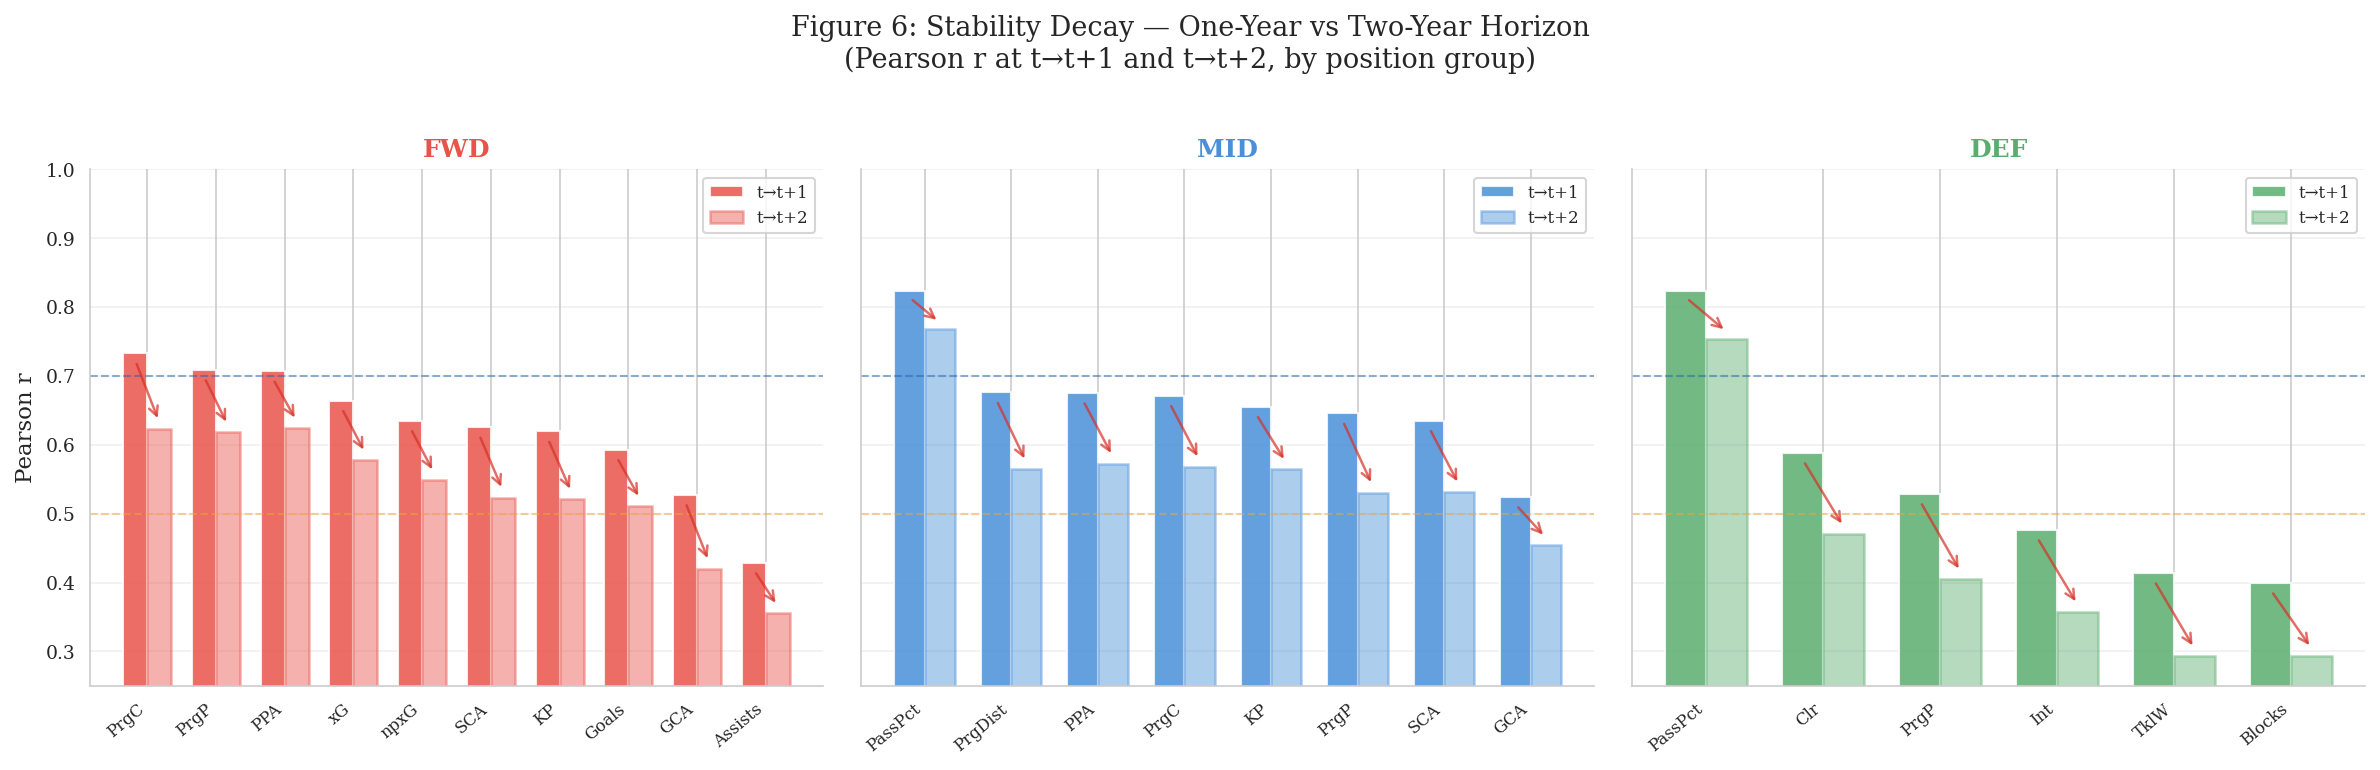

In [16]:
# ============================================================================
# CELL 13: FIGURE 6 — MULTI-YEAR STABILITY DECAY PLOT
# ============================================================================
# Visualises r(t→t+1) vs r(t→t+2) per position group.
# Shows which metrics decay and which remain stable over two seasons.

plt.rcParams.update(PUB_STYLE)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Figure 6: Stability Decay — One-Year vs Two-Year Horizon\n'
             '(Pearson r at t→t+1 and t→t+2, by position group)',
             fontsize=13, y=1.02)

for ax, pos in zip(axes, POS_BUCKETS):
    df_pos = df_t2_stability[df_t2_stability['Pos'] == pos].copy()
    df_pos = df_pos.sort_values('r_t1', ascending=False)

    metrics = df_pos['Metric'].tolist()
    x      = np.arange(len(metrics))
    width  = 0.35

    r_t1_vals = df_pos['r_t1'].values
    r_t2_vals = df_pos['r_t2'].values

    bars1 = ax.bar(x - width/2, r_t1_vals, width,
                   label='t→t+1', color=POS_COLOURS[pos], alpha=0.85)
    bars2 = ax.bar(x + width/2, r_t2_vals, width,
                   label='t→t+2', color=POS_COLOURS[pos], alpha=0.45,
                   edgecolor=POS_COLOURS[pos], linewidth=1.2)

    # Annotate decay arrows for metrics with Δr < -0.03
    for i, (r1, r2) in enumerate(zip(r_t1_vals, r_t2_vals)):
        if not pd.isna(r1) and not pd.isna(r2) and (r2 - r1) < -0.03:
            ax.annotate('', xy=(x[i] + width/2, r2 + 0.01),
                        xytext=(x[i] - width/2, r1 - 0.01),
                        arrowprops=dict(arrowstyle='->', color='#D73027',
                                        lw=1.2, alpha=0.7))

    ax.axhline(THRESH_HIGH, color='#2166AC', linestyle='--', lw=1, alpha=0.5)
    ax.axhline(THRESH_MOD,  color='#F4A736', linestyle='--', lw=1, alpha=0.5)
    ax.set_ylim(0.25, 1.0)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=40, ha='right', fontsize=8)
    ax.set_title(f'{pos}', fontsize=12, color=POS_COLOURS[pos], fontweight='bold')
    ax.set_ylabel('Pearson r' if ax == axes[0] else '')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_fig('fig6_stability_decay', fig)
plt.show()

In [17]:
# ============================================================================
# CELL 14: SAVE ALL RESULTS
# ============================================================================

df_stability.to_csv('stability_main.csv', index=False)
df_age_stability.to_csv('stability_by_age.csv', index=False)
df_league_stability.to_csv('stability_by_league.csv', index=False)
df_fisher.to_csv('stability_fisher_tests.csv', index=False)
df_t2_stability.to_csv('stability_t2.csv', index=False)
df_sensitivity.to_csv('stability_sensitivity.csv', index=False)
df_sweep.to_csv('sensitivity_min90s.csv', index=False)

print("Results saved:")
print(f"  stability_main.csv           — {len(df_stability)} rows  (main table)")
print(f"  stability_by_age.csv         — {len(df_age_stability)} rows  (age extension)")
print(f"  stability_by_league.csv      — {len(df_league_stability)} rows  (league extension)")
print(f"  stability_fisher_tests.csv   — {len(df_fisher)} rows  (age group significance tests)")
print(f"  stability_t2.csv             — {len(df_t2_stability)} rows  (t→t+2 decay)")
print(f"  stability_sensitivity.csv    — {len(df_sensitivity)} rows  (role-change sensitivity)")
print(f"  sensitivity_min90s.csv       — {len(df_sweep)} rows  (MIN_90S sweep)")

print(f"\nFigures saved:")
print(f"  fig1_stability_heatmap")
print(f"  fig2A_scatter_fwd / fig2B_scatter_mid / fig2C_scatter_def")
print(f"  fig3_overlap_comparison")
print(f"  fig4_stability_by_age")
print(f"  fig5_stability_by_league")
print(f"  fig6_stability_decay")
print(f"  fig7_min90s_sensitivity")

print(f"\nAnalysis complete — ready to write paper.")

Results saved:
  stability_main.csv           — 24 rows  (main table)
  stability_by_age.csv         — 72 rows  (age extension)
  stability_by_league.csv      — 120 rows  (league extension)
  stability_fisher_tests.csv   — 72 rows  (age group significance tests)
  stability_t2.csv             — 24 rows  (t→t+2 decay)
  stability_sensitivity.csv    — 24 rows  (role-change sensitivity)
  sensitivity_min90s.csv       — 9 rows  (MIN_90S sweep)

Figures saved:
  fig1_stability_heatmap
  fig2A_scatter_fwd / fig2B_scatter_mid / fig2C_scatter_def
  fig3_overlap_comparison
  fig4_stability_by_age
  fig5_stability_by_league
  fig6_stability_decay
  fig7_min90s_sensitivity

Analysis complete — ready to write paper.
